In [5]:
import matplotlib.pyplot as plt

import pandas as pd

#Line plot : (used to analyze time series / time based  dataset) and used to analyze the trends and patterns.

# Variation with respect to time , whether it is increases or decreases or constant with time
# or
#Conclusion of Line plot : with respect to x , y is increasing or decreasing , and we can use that to find the pattern .
# ==============================
#syntax : plt.plot(x,y)

# ==============================
# year = [2021,2022, 2023, 2024,2025]
# sales = [10000,7000,15000,17000,18000]

# df = pd.DataFrame(year, sales)

# df.head()

# =============================


df = pd.DataFrame({ 'Year' : [2021,2022, 2023, 2024,2025] , 'Sales' : [10000,9000,15000,17000,18000] })

# =============================
# df = pd.DataFrame({

#                     'rollno' : [10, 23, 25, 12, 35, 58],
#                     'marks': [60,39, 40, 39, 25,55]
# })

# =============================
# To sort the values of columns in the dataFrame

# df = df.sort_values('Sales')

df.head()






,Year,Sales
0,2021,10000
1,2022,9000
2,2023,15000
3,2024,17000
4,2025,18000


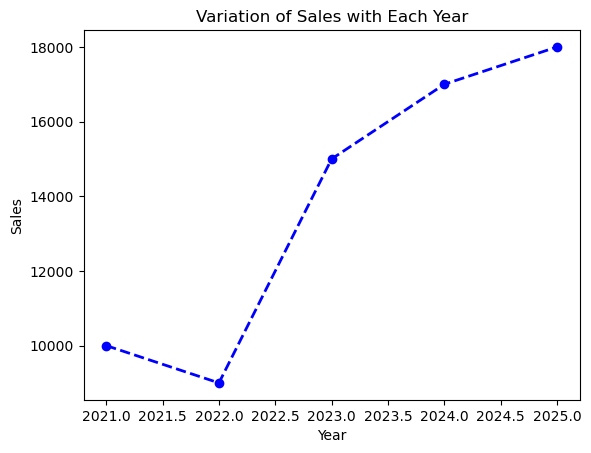

In [7]:

# plt.plot(year, sales , marker = 'o' , linestyle = 'solid', linewidth = 2)

#      or 

plt.plot(df['Year'], df['Sales'] , marker = 'o' , linewidth = 2, linestyle = '--' , color = 'blue')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Variation of Sales with Each Year')
plt.show()

In [9]:




df = pd.read_csv("googleplaystore.csv")
df.head()

# for line plot we cannot plot directly plt.plot(df['Year'], df['Ratings']) as this will give me a zig zag line plot..

# so first we need to group that ratings based on year and then we can use AVG to find average ratings then we can plot year vs Ratings...

# first extract year from the last updated..



# df['Last Updated'] = pd.to_datetime(df['Last Updated'])  
#ValueError: time data "1.0.19" doesn't match format "%B %d, %Y", at position 1348



# so we will use the replace to get it in a correct format..

df['Last Updated'] = df['Last Updated'].replace({"1.0.19":"January 1, 2019"})

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"5,00,000",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"50,00,000",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"5,00,00,000",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"1,00,000",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [11]:
# Now we will use to convert it into date time format..
df['Last Updated'] = pd.to_datetime(df['Last Updated'])  
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10841 non-null  object        
 1   Category        10841 non-null  object        
 2   Rating          9367 non-null   float64       
 3   Reviews         10841 non-null  object        
 4   Size            10841 non-null  object        
 5   Installs        10841 non-null  object        
 6   Type            10840 non-null  object        
 7   Price           10841 non-null  object        
 8   Content Rating  10840 non-null  object        
 9   Genres          10841 non-null  object        
 10  Last Updated    10841 non-null  datetime64[ns]
 11  Current Ver     10833 non-null  object        
 12  Android Ver     10838 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(11)
memory usage: 1.1+ MB


In [13]:

# we will extract the year from the Last Updated column...
df["Year"] =df["Last Updated"].dt.year
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"5,00,000",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"50,00,000",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"5,00,00,000",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"1,00,000",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2018


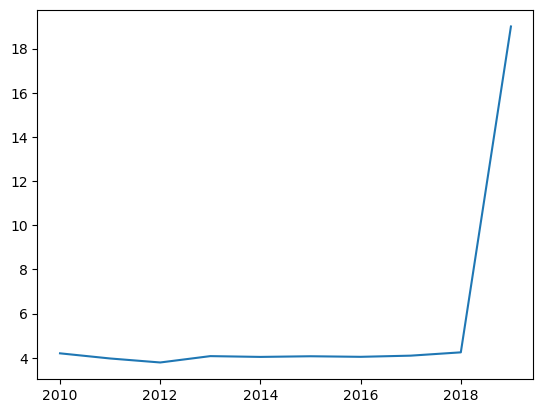

In [15]:

#now we have to find avg ratings per year ,so group the year  and then find mean of the ratings.
group_year = df.groupby('Year')

year_avg_ratings = group_year['Rating'].mean()

year_avg_ratings  # this doesn't give a dataframe as output .. it gives series.


plt.plot(year_avg_ratings)



In [17]:
year_avg_ratings.index  # this has Index and values in it so if we try plotting the line plot it will work ,however it will not be the crt 
                        #plot for the Year vs Ratings..

Index([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019], dtype='int32', name='Year')

In [19]:
year_avg_ratings.values  # this has Index and values in it so if we try plotting the line plot it will work ,however it will not be the crt 
                        #plot for the Year vs Ratings..

array([ 4.2       ,  3.96666667,  3.78571429,  4.07340426,  4.03789474,
        4.06726804,  4.04178187,  4.09479306,  4.24452981, 19.        ])

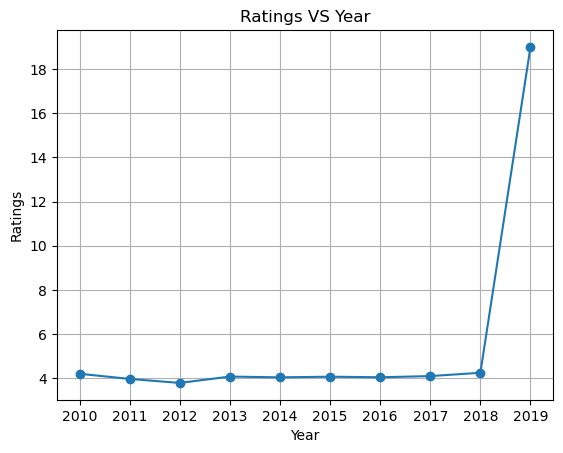

In [21]:

# Here in the plot , it is ignoring the 2019 value of the year.. to display the make use of the xticks..

plt.plot(year_avg_ratings, marker='o')
plt.xticks(year_avg_ratings.index)

plt.xlabel('Year')
plt.ylabel('Ratings')
plt.title("Ratings VS Year")
plt.grid()

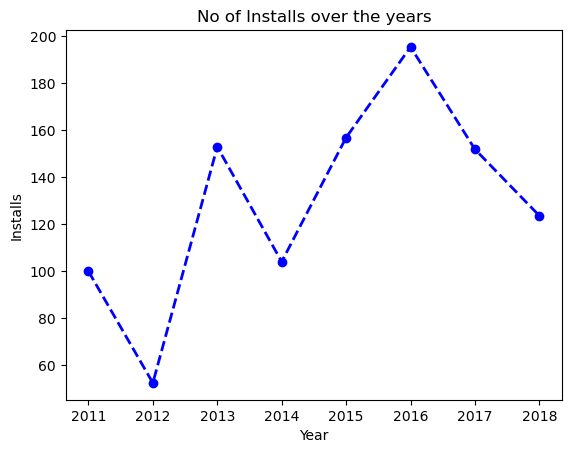

In [23]:
#How has the no of Installs grown over the years..


#Cleaning the Installs.
df['Installs'] = df['Installs'].replace('M' , ' ' , regex = True)

#converting it into Numeric ,if it is in string or not numeric
df['Installs'] = pd.to_numeric(df['Installs'] , errors = 'coerce')

#extracting the Year from the last updated..
df['Year'] = df['Last Updated'].dt.year
df['Year'] = pd.to_numeric(df['Year'])

avg_installs = df.groupby('Year')['Installs'].mean()
plt.plot(avg_installs, marker= 'o', linestyle = '--', linewidth = 2, color = 'blue')

plt.title('No of Installs over the years')
plt.xlabel('Year')
plt.ylabel('Installs')
plt.show()

In [25]:

#How has the avg price app changed over time..

df['Year'] =df["Last Updated"].dt.year

df.head()



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,NaN,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,NaN,Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,NaN,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,NaN,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,NaN,Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2018


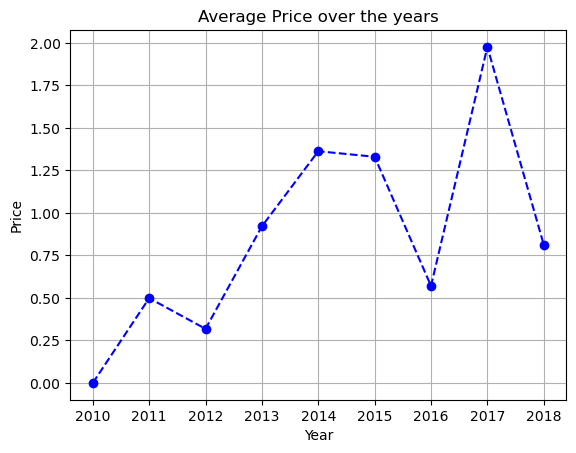

In [27]:
df['Price'] = df['Price'].str.replace('$', ' ' )
df['Price'] = df['Price'].replace({'Everyone':'None'})


df['Price'] = pd.to_numeric(df['Price'] , errors = 'coerce')


avg_price = df.groupby('Year')['Price'].mean()

plt.plot(avg_price ,marker = 'o', linestyle = '--', color = 'blue')
plt.title('Average Price over the years')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()
plt.show()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10841 non-null  object        
 1   Category        10841 non-null  object        
 2   Rating          9367 non-null   float64       
 3   Reviews         10841 non-null  object        
 4   Size            10841 non-null  object        
 5   Installs        1804 non-null   float64       
 6   Type            10840 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10841 non-null  object        
 10  Last Updated    10841 non-null  datetime64[ns]
 11  Current Ver     10833 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Year            10841 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), object(9)


In [31]:
#Convert the type of Size and Installs to float type..



df['Size']  = df['Size'].replace({'Varies with device':'0', 'M':'', 'k':'', ',':'','+':''}, regex=True)

df['Size'] = df['Size'].astype(float)
df['Reviews'] = df['Reviews'].astype(float)

error: nothing to repeat at position 0

In [ ]:
# How has the number of apps realeased over the years.


df['Year'] = df['Last Updated'].dt.year

df['Year'] = pd.to_numeric(df['Year'])

no_of_apps = df.groupby('Year')['App'].count()

plt.plot(no_of_apps, marker='o', linewidth = 2, color = 'blue', linestyle = '--')
plt.title('No of apps Relased over the Years')
plt.xlabel("Year")
plt.ylabel('No of Apps')
plt.grid()
plt.show()

In [ ]:
 #2) Scatter plot..

# Note : In Line plot and Scatter plot we use only numberical based columns..

#covariance : Variation of X with respect to y ( only numbers columns) 
# positive covariance : if x incre the y increases ( directly proportional) 
# Negatvie covariance  : if x incre then y decreases.( Inversly proportional) 
# Zero Covariance : No relation between two variables..( gold price vs IPL score)



# There is 3 difference between covariance and Correlation..

#covariance shows relation between two columns while correlation shows relation between more than two columns..
#covariance shows direction (positive or negative) while correlation doesn't shows direction 
#covariance does not show strong relation , but correlation shows relation along with the how strong the relation is?

#(correlation value is +90(0.90) = strong relation ( if x incr then y incre or if x dec then y decr)
#(0 = No realtion close to zero (ex 0.5, -0.2) 
#(-95 (-0.95)  = strong  relation : if x incr then y incre or if x dec then y decr ) 



# Scatter Plot : It is used to find outliers and correlation between numerical columns..

#syntax = plt.scatter(x,y)

#cleaning of price is already done
# df['Price'] = df['Price'].replace('$', '')

# df['Price']= pd.to_numeric(df['Price'])

df['Rating'] = pd.to_numeric(df['Rating'])
df['Installs'] = pd.to_numeric(df['Installs'])


plt.scatter( df['Rating'], df['Price'] )





In [ ]:
# # Remove commas
# df['Size'] = df['Size'].str.replace(',', '', regex=True)

# # Remove unwanted strings
# df['Size'] = df['Size'].replace('M','', regex=True)
# df['Size'] = df['Size'].replace('Varies with device','', regex=True)
# df['Size'] = df['Size'].replace('k','', regex=True)



#Alternative way to replace the Errors by using dictionary..

# df['Price'] = df['Price'].replace({'$':'', 'Everyone':'', ',':''}, regex=True)

# df['Size']  = df['Size'].replace({'Varies with device':'', 'M':'', 'k':'', ',':''}, regex=True)

# Convert to numeric
# this will replace all the values with the NaN values.. if the values are in object or the string type.

# df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
# df['Price'] = pd.to_numeric(df['Price'], errors='coerce')





In [ ]:
df_clean = df[['Rating', 'Size', 'Price','Year','Reviews']].dropna()
df.corr(numeric_only = True)

In [37]:

#outliers..

# Here variance shows the how far the actual values are  from the mean position but it is the squared value of the object
#( E(xi - x bar) ^2 / sigma / n ** 1/2  however std deviation shows the deviation from the mean postion but it is the actual value. 

# variance should not be compared to any values such as mean or something as it is squared values of the obj, use std deviation for comparsion


#Threee Conclusions..
#variance and std deviation shows whether the data is consistent or inconsistent..
# High variance - values are far from the mean .. : Data points are scatterd
#Low variance = Values are near to the mean..

In [40]:
#create one function to detect outliers in the Ratings Columns..

            
#Calculating the z score values..

def z_score(col):
    x_mean = df[col].mean()
    x_std = df[col].std()
    X = df[col]
    return (X - x_mean) / x_std
  

df['Rating_z'] = z_score('Rating')
df['Rating_z']


# Detecting the outliers based on the values of z score, if  abs(col) > 3 ,then it is an outlier..

def outliers_in_ratings(col):
    l1 = []
    for val in df[col]:
        if abs(val) > 3:
            l1.append(val)
    return l1

l = (outliers_in_ratings('Rating_z'))
print(l)
print()
print(len(l))




[-4.2672213209953656, -3.150799563487433, -3.150799563487433, -3.150799563487433, -4.2672213209953656, -5.941853957257264, -4.2672213209953656, -3.150799563487433, -3.5229401493234107, -3.150799563487433, -3.7090104422413988, -4.6393619068313425, -4.081151028077376, -5.941853957257264, -4.453291613913354, -3.5229401493234107, -3.3368698564054218, -3.7090104422413988, -4.453291613913354, -3.3368698564054218, -3.3368698564054218, -3.150799563487433, -4.2672213209953656, -3.150799563487433, -3.7090104422413988, -4.453291613913354, -4.825432199749331, -4.2672213209953656, -3.150799563487433, -4.6393619068313425, -3.3368698564054218, -3.7090104422413988, -4.2672213209953656, -4.081151028077376, -4.081151028077376, -3.5229401493234107, -5.941853957257264, -3.3368698564054218, -3.5229401493234107, -4.6393619068313425, -3.8950807351593877, -3.8950807351593877, -3.3368698564054218, -4.2672213209953656, -3.150799563487433, -5.941853957257264, -3.5229401493234107, -5.197572785585309, -3.709010442

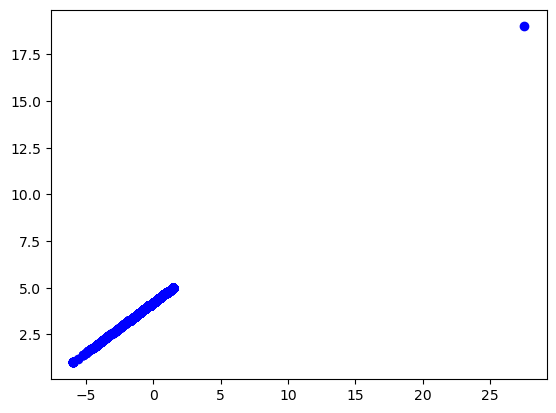

In [42]:

plt.scatter(df['Rating_z'], df['Rating'], color = 'blue')


{'whiskers': [<matplotlib.lines.Line2D at 0x16a8651c0>,
 'caps': [<matplotlib.lines.Line2D at 0x16a865640>,
 'boxes': [<matplotlib.lines.Line2D at 0x16a864f50>],
 'medians': [<matplotlib.lines.Line2D at 0x16a865c10>],
 'fliers': [<matplotlib.lines.Line2D at 0x16a865f10>],
 'means': []}

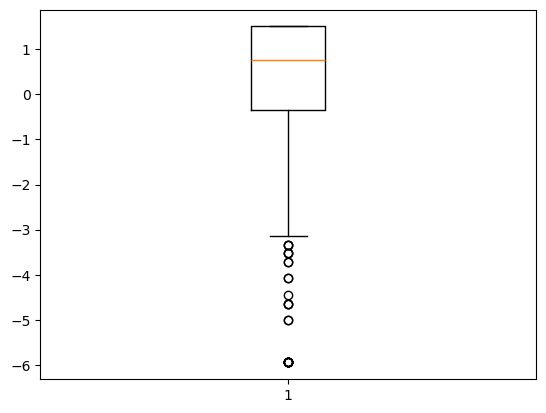

In [44]:
#Box Plot : Used to Identify the outlier in the columns.

df = df.dropna()
plt.boxplot(df['Rating_z'])  # we wont get the graph, coz it has null values ..so , drop the null values.



In [46]:
q1 = df['Rating_z'].quantile(0.25)

q2 = df['Rating_z'].quantile(0.50)

q3 = df['Rating_z'].quantile(0.75)

print(q1, q2, q3,end=" " )

-0.3597451697176018 0.75667658779033 1.5009577594622856 

{'whiskers': [<matplotlib.lines.Line2D at 0x16a85a660>,
 'caps': [<matplotlib.lines.Line2D at 0x16a85ac30>,
 'boxes': [<matplotlib.lines.Line2D at 0x16a85a330>],
 'medians': [<matplotlib.lines.Line2D at 0x16a85ae10>],
 'fliers': [<matplotlib.lines.Line2D at 0x16a85b0b0>],
 'means': []}

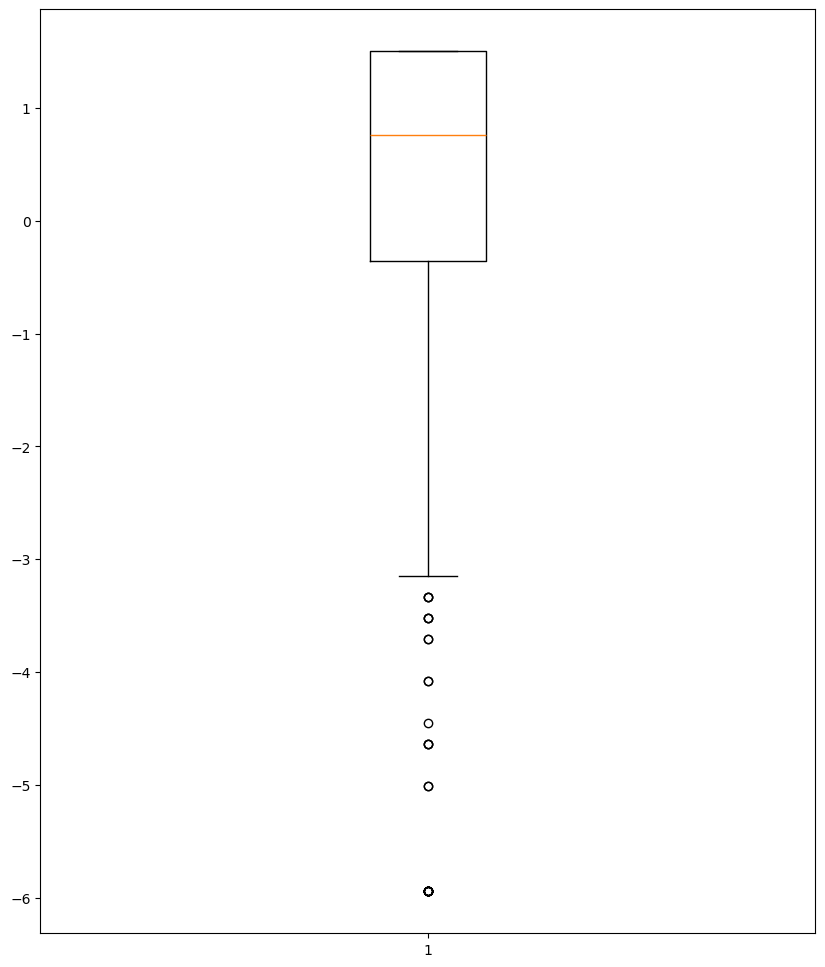

In [48]:
plt.figure(figsize = (10, 12)) # It assigns dimension in inches..

plt.boxplot(df['Rating_z'])


In [50]:
# Print the entire row of Ratings column , where ever we have the outliers print the entire row , not the entire dataframee...


outliers = df[(df['Rating_z'] < -0.359745) | (df['Rating_z'] > 0.5706062)]
outliers


#It only returns the rating_z column values..

# def rating_outlier(col):
#     return df[(df[col] < q1) | (df[col] > q3)][col]

# Rating_z = rating_outlier('Rating_z')
# print(Rating_z)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year,Rating_z
481,AMBW Dating App: Asian Men Black Women Interra...,DATING,3.5,2,17M,100.0,Paid,7.99,Mature 17+,Dating,2017-01-21,1.0.1,4.0 and up,2017,-1.290097
608,Chat Kids - Chat Room For Kids,DATING,4.7,6,4.9M,100.0,Free,0.00,Mature 17+,Dating,2018-07-24,1.0,4.0.3 and up,2018,0.942747
611,MouseMingle,DATING,2.7,3,3.9M,100.0,Free,0.00,Mature 17+,Dating,2018-07-17,1.0.0,4.4 and up,2018,-2.778659
615,Awake Dating,DATING,5.0,2,70M,100.0,Free,0.00,Mature 17+,Dating,2018-07-24,2.2.9,4.4 and up,2018,1.500958
616,Live Chat - Free Video Chat Rooms,DATING,4.8,20,4.9M,500.0,Free,0.00,Mature 17+,Dating,2018-07-15,8.2,4.0.3 and up,2018,1.128817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10767,NFP 2018,EVENTS,4.8,8,16M,500.0,Free,0.00,Everyone,Events,2018-01-09,1.0.3,4.2 and up,2018,1.128817
10776,Monster Ride Pro,GAME,5.0,1,24M,10.0,Free,0.00,Everyone,Racing,2018-03-05,2.0,2.3 and up,2018,1.500958
10810,Fr Lupupa Sermons,BUSINESS,4.8,19,21M,100.0,Free,0.00,Everyone,Business,2018-06-12,1.0,4.4 and up,2018,1.128817
10834,FR Calculator,FAMILY,4.0,7,2.6M,500.0,Free,0.00,Everyone,Education,2017-06-18,1.0.0,4.1 and up,2017,-0.359745


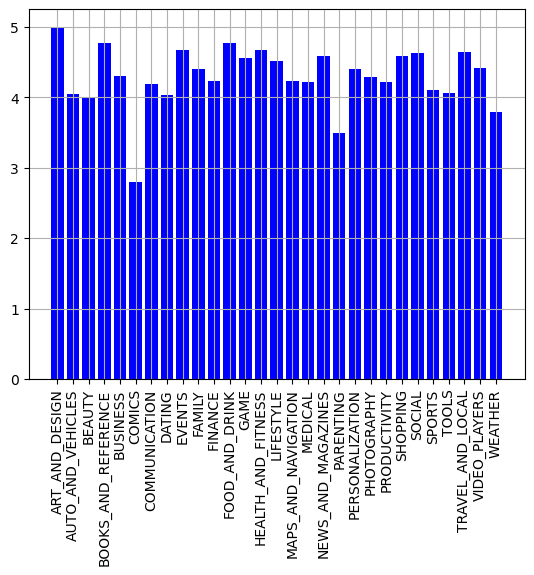

In [52]:
# Bar Plot...

# It is used for Grouped data 

cat_rating = df.groupby('Category')['Rating'].mean()
cat_rating
plt.bar(cat_rating.index, cat_rating.values , color = 'blue' )

#xticks are used to show the xlabels in proper format
plt.xticks(rotation = 90)

plt.grid()
#Hide the unwnated text being shown in the visualization
plt.show()


In [54]:
def installs(val):
    if ',' in val or '+' in val:
        return float(val.replace(',','').replace('+',''))
    if val == 'Free':
        return None

df['Installs'] = df['Installs'].replace(',', '')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 647 entries, 481 to 10837
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             647 non-null    object        
 1   Category        647 non-null    object        
 2   Rating          647 non-null    float64       
 3   Reviews         647 non-null    object        
 4   Size            647 non-null    object        
 5   Installs        647 non-null    float64       
 6   Type            647 non-null    object        
 7   Price           647 non-null    float64       
 8   Content Rating  647 non-null    object        
 9   Genres          647 non-null    object        
 10  Last Updated    647 non-null    datetime64[ns]
 11  Current Ver     647 non-null    object        
 12  Android Ver     647 non-null    object        
 13  Year            647 non-null    int32         
 14  Rating_z        647 non-null    float64       
dtypes: date

/var/folders/zx/4wml1k7n6ml37j348fx1w4400000gn/T/ipykernel_34534/320856131.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs'] = df['Installs'].replace(',', '')


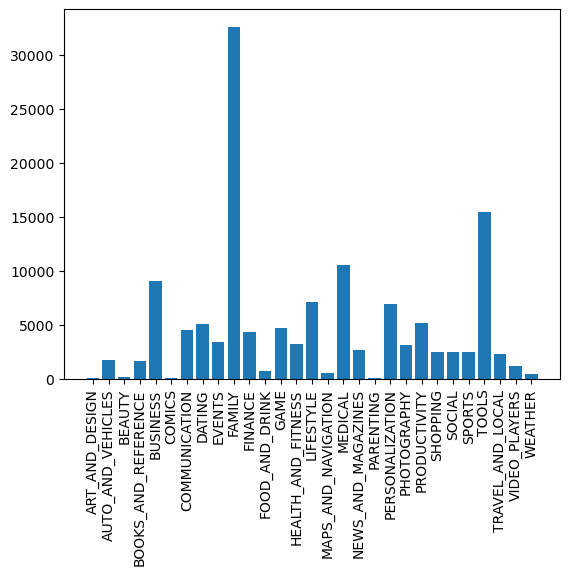

In [56]:



Cat_Install = df.groupby('Category')['Installs'].sum()

# Cat_Install

plt.bar(Cat_Install.index, Cat_Install.values)
plt.xticks(rotation = 90)
plt.show()

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 647 entries, 481 to 10837
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             647 non-null    object        
 1   Category        647 non-null    object        
 2   Rating          647 non-null    float64       
 3   Reviews         647 non-null    object        
 4   Size            647 non-null    object        
 5   Installs        647 non-null    float64       
 6   Type            647 non-null    object        
 7   Price           647 non-null    float64       
 8   Content Rating  647 non-null    object        
 9   Genres          647 non-null    object        
 10  Last Updated    647 non-null    datetime64[ns]
 11  Current Ver     647 non-null    object        
 12  Android Ver     647 non-null    object        
 13  Year            647 non-null    int32         
 14  Rating_z        647 non-null    float64       
dtypes: date

In [60]:
category_vc = df['Category'].value_counts()

category_vc.head(10)

Category
FAMILY                142
TOOLS                  58
MEDICAL                57
BUSINESS               48
PERSONALIZATION        39
GAME                   34
LIFESTYLE              34
PRODUCTIVITY           27
COMMUNICATION          25
HEALTH_AND_FITNESS     20
Name: count, dtype: int64

In [62]:
category_vc.index

Index(['FAMILY', 'TOOLS', 'MEDICAL', 'BUSINESS', 'PERSONALIZATION', 'GAME',
       'LIFESTYLE', 'PRODUCTIVITY', 'COMMUNICATION', 'HEALTH_AND_FITNESS',
       'DATING', 'FINANCE', 'SOCIAL', 'SPORTS', 'NEWS_AND_MAGAZINES',
       'PHOTOGRAPHY', 'SHOPPING', 'EVENTS', 'TRAVEL_AND_LOCAL',
       'MAPS_AND_NAVIGATION', 'BOOKS_AND_REFERENCE', 'AUTO_AND_VEHICLES',
       'FOOD_AND_DRINK', 'VIDEO_PLAYERS', 'BEAUTY', 'PARENTING', 'WEATHER',
       'COMICS', 'ART_AND_DESIGN'],
      dtype='object', name='Category')

In [64]:
category_vc.values

array([142,  58,  57,  48,  39,  34,  34,  27,  25,  20,  20,  18,  16,
        15,  15,  14,  13,  11,   7,   7,   6,   6,   4,   4,   2,   2,
         1,   1,   1])

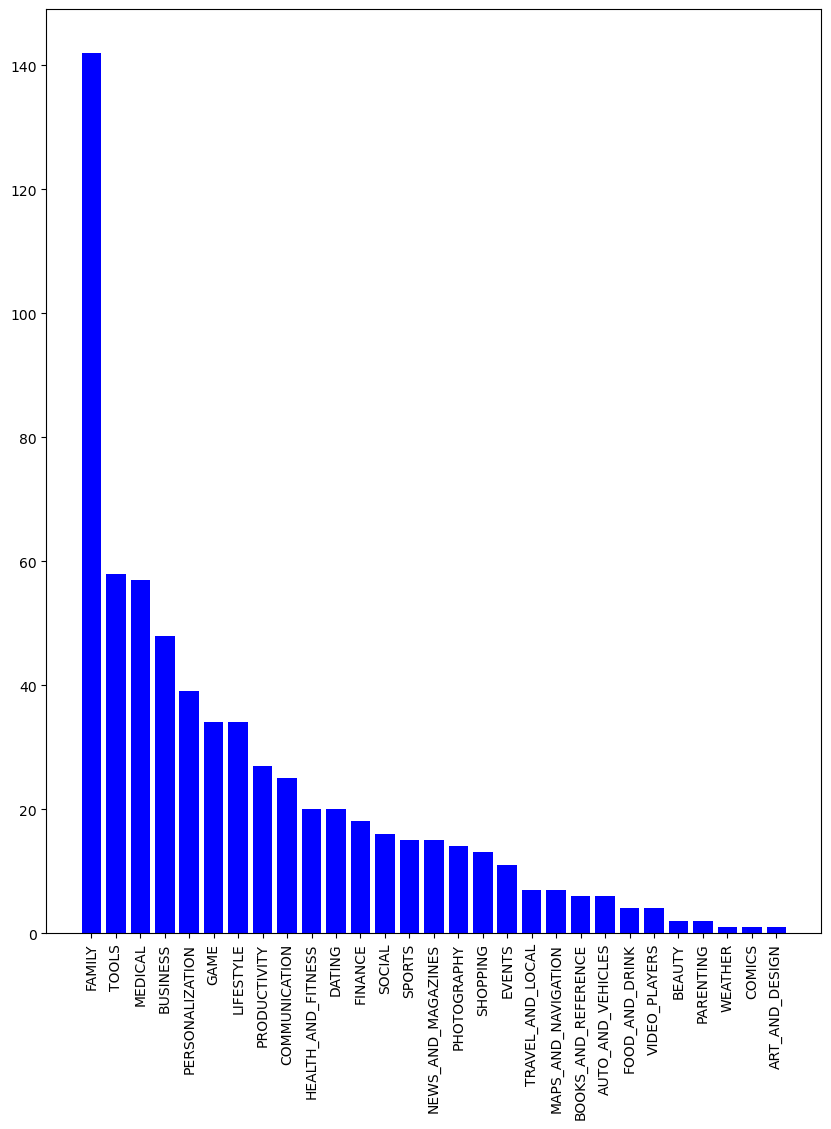

In [66]:
plt.figure(figsize=(10,12)) # figsize is given as input in the inches..

plt.bar(category_vc.index, category_vc.values,color = 'blue')

plt.xticks(rotation = 90)
plt.show()

In [68]:
# using groupy and count to plot the count of each category..


cat_count = df.groupby('Category').count()
cat_count




,App,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year,Rating_z
Category,,,,,,,,,,,,,,
ART_AND_DESIGN,1,1,1,1,1,1,1,1,1,1,1,1,1,1
AUTO_AND_VEHICLES,6,6,6,6,6,6,6,6,6,6,6,6,6,6
BEAUTY,2,2,2,2,2,2,2,2,2,2,2,2,2,2
BOOKS_AND_REFERENCE,6,6,6,6,6,6,6,6,6,6,6,6,6,6
BUSINESS,48,48,48,48,48,48,48,48,48,48,48,48,48,48
COMICS,1,1,1,1,1,1,1,1,1,1,1,1,1,1
COMMUNICATION,25,25,25,25,25,25,25,25,25,25,25,25,25,25
DATING,20,20,20,20,20,20,20,20,20,20,20,20,20,20
EVENTS,11,11,11,11,11,11,11,11,11,11,11,11,11,11


In [70]:
# plt.bar(cat_count.index,cat_count.values,color = 'blue')

cat_count.values   # this gives me a array of all the columns values.. which will mismatch with the dimension of index values..

array([[  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1],
       [  6,   6,   6,   6,   6,   6,   6,   6,   6,   6,   6,   6,   6,
          6],
       [  2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
          2],
       [  6,   6,   6,   6,   6,   6,   6,   6,   6,   6,   6,   6,   6,
          6],
       [ 48,  48,  48,  48,  48,  48,  48,  48,  48,  48,  48,  48,  48,
         48],
       [  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1],
       [ 25,  25,  25,  25,  25,  25,  25,  25,  25,  25,  25,  25,  25,
         25],
       [ 20,  20,  20,  20,  20,  20,  20,  20,  20,  20,  20,  20,  20,
         20],
       [ 11,  11,  11,  11,  11,  11,  11,  11,  11,  11,  11,  11,  11,
         11],
       [142, 142, 142, 142, 142, 142, 142, 142, 142, 142, 142, 142, 142,
        142],
       [ 18,  18,  18,  18,  18,  18,  18,  18,  18,  18,  18,  18,  18,
         18],
       [  4,   4,   4,   4,   4,   4,   4, 

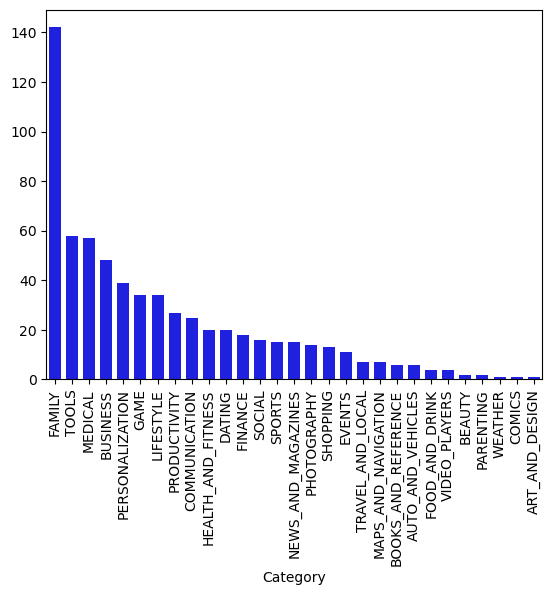

In [72]:

# without using the matplotlib library.. using the seaborn library..
# category_vc.plot(kind= 'bar')

import seaborn as sns

sns.barplot(x=category_vc.index, y = category_vc.values, color= 'blue' , width= 0.7)

plt.xticks(rotation = 90)
plt.show()

In [73]:

genres_vc = df['Genres'].value_counts()
genres_vc


Genres
Tools                        58
Education                    57
Medical                      57
Entertainment                49
Business                     48
Personalization              39
Lifestyle                    34
Productivity                 27
Communication                25
Dating                       20
Health & Fitness             20
Finance                      18
Social                       16
Sports                       15
News & Magazines             15
Photography                  14
Arcade                       14
Shopping                     13
Events                       11
Casual                       10
Maps & Navigation             7
Action                        7
Travel & Local                7
Auto & Vehicles               6
Books & Reference             6
Simulation                    5
Puzzle                        5
Food & Drink                  4
Role Playing                  4
Video Players & Editors       4
Education;Education           3
E

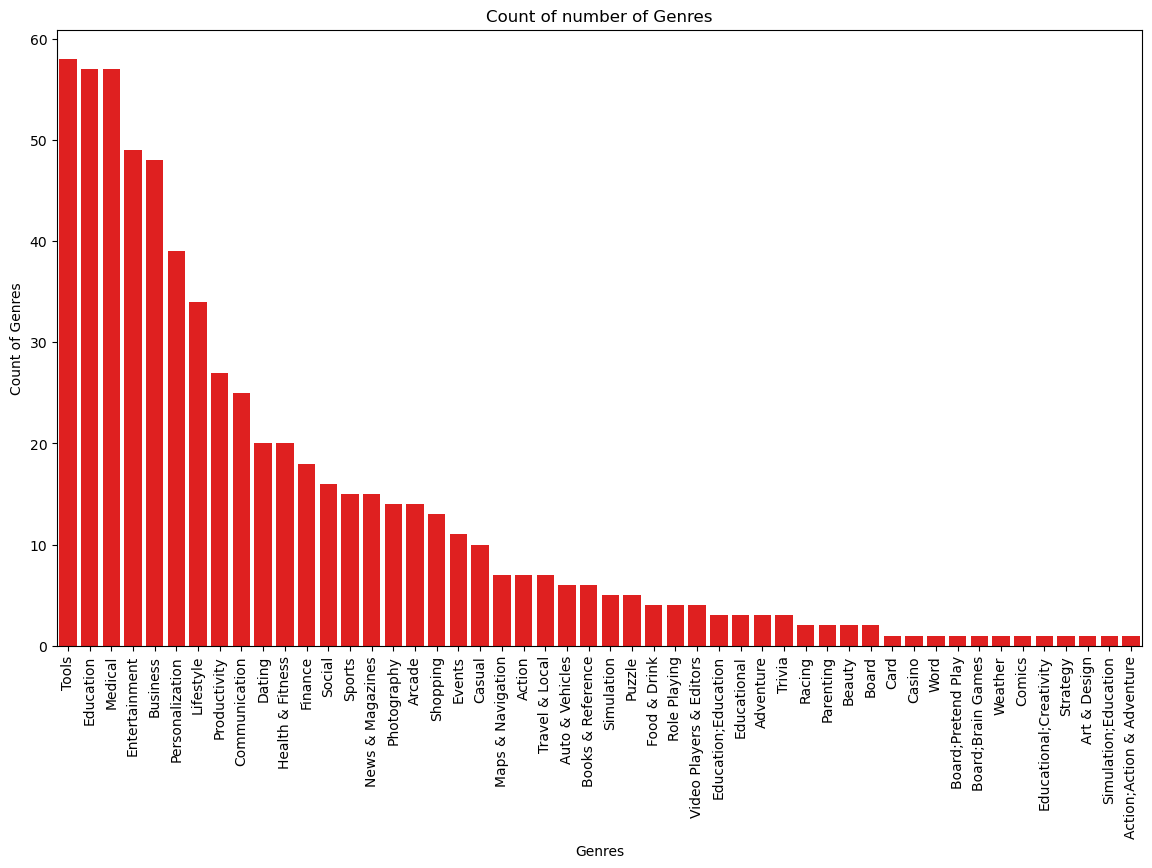

In [74]:

plt.figure(figsize=(14,8))
sns.barplot(x=genres_vc.index, y=genres_vc.values,color = 'red' )

plt.xlabel('Genres')
plt.ylabel('Count of Genres')
plt.title("Count of number of Genres")
plt.xticks(rotation = 90)
# plt.grid()
plt.show()


In [75]:
# df.head()
cat_rat = df.groupby('Category')['Rating'].mean()

cat_rat.head(10)

Category
ART_AND_DESIGN         5.000000
AUTO_AND_VEHICLES      4.050000
BEAUTY                 4.000000
BOOKS_AND_REFERENCE    4.766667
BUSINESS               4.300000
COMICS                 2.800000
COMMUNICATION          4.192000
DATING                 4.040000
EVENTS                 4.672727
FAMILY                 4.400704
Name: Rating, dtype: float64

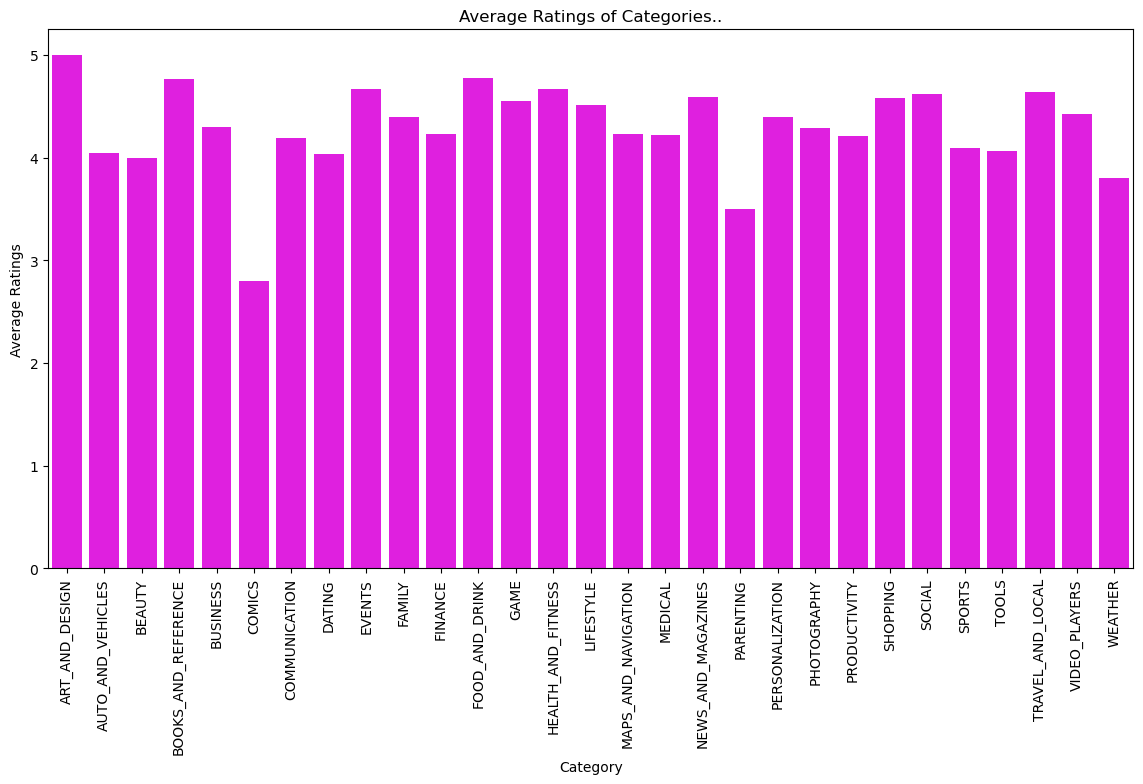

In [76]:
plt.figure(figsize=(14,7))
sns.barplot(x = cat_rat.index, y = cat_rat.values, color = 'magenta')

plt.xticks(rotation = 90)
plt.xlabel('Category')
plt.ylabel('Average Ratings')
plt.title('Average Ratings of Categories..')
# plt.grid()
plt.show()

In [78]:
# Home work
# import data, perform data cleaning , feature engineering , visuals, apply all methods.

import pandas as pd
df1 = pd.read_csv('netflix.csv')
df1.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [80]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [83]:
df1.shape

(8807, 12)

In [88]:
df1.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [90]:
df1['date_added'] = pd.to_datetime(df1['date_added'])

df1.head(10)


count_type = df1.groupby('release_year')['type'].count()
count_type

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: type, Length: 74, dtype: int64

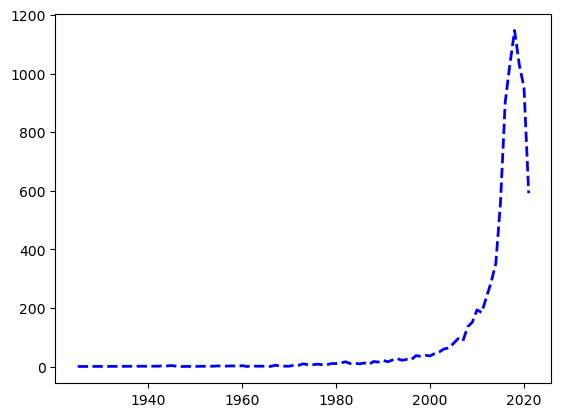

In [92]:
import matplotlib.pyplot as plt

plt.plot(count_type.index, count_type.values, linestyle = '--', linewidth = 2, color = 'blue')

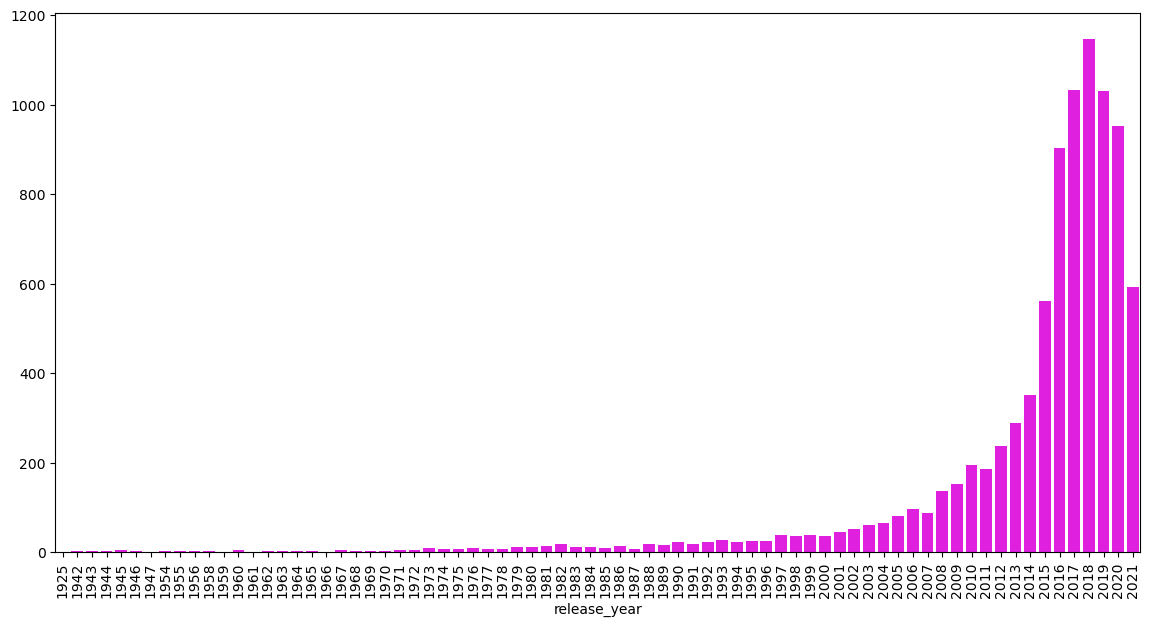

In [94]:
import seaborn as sns

plt.figure(figsize =(14,7))

sns.barplot(x = count_type.index, y = count_type.values , color = 'magenta')

plt.xticks(rotation = 90)
plt.show()

In [96]:
#pie chart...

# used to show percentage of values of categorical or groupped values..

#syntax .
# plt.pie(values, labels, autopct = '%1.1f%%')   autopct is used of showing percentage..

category_vc.head(10)

Category
FAMILY                142
TOOLS                  58
MEDICAL                57
BUSINESS               48
PERSONALIZATION        39
GAME                   34
LIFESTYLE              34
PRODUCTIVITY           27
COMMUNICATION          25
HEALTH_AND_FITNESS     20
Name: count, dtype: int64

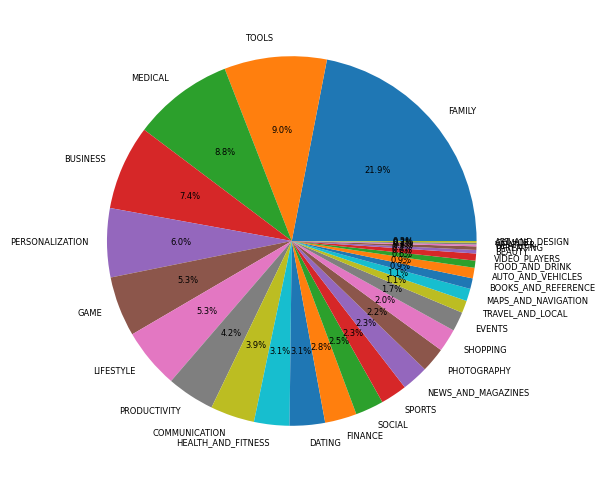

In [98]:
plt.figure(figsize=(10, 6))
plt.pie(category_vc.values, labels = category_vc.index,autopct = "%1.1f%%", textprops = {'fontsize': 6})

plt.show()

In [100]:
# out of all the columns , if i have to select the columns which are of object type then..

df.select_dtypes(include ='object') # returns all objects columns

# df.select_dtypes(include = 'object').nunique() # to get all the unique values..

,App,Category,Reviews,Size,Type,Content Rating,Genres,Current Ver,Android Ver
481,AMBW Dating App: Asian Men Black Women Interra...,DATING,2,17M,Paid,Mature 17+,Dating,1.0.1,4.0 and up
605,Cardi B Live Stream Video Chat - Prank,DATING,28,3.4M,Free,Everyone,Dating,2.5,4.0.3 and up
608,Chat Kids - Chat Room For Kids,DATING,6,4.9M,Free,Mature 17+,Dating,1.0,4.0.3 and up
611,MouseMingle,DATING,3,3.9M,Free,Mature 17+,Dating,1.0.0,4.4 and up
615,Awake Dating,DATING,2,70M,Free,Mature 17+,Dating,2.2.9,4.4 and up
...,...,...,...,...,...,...,...,...,...
10776,Monster Ride Pro,GAME,1,24M,Free,Everyone,Racing,2.0,2.3 and up
10805,Scoreboard FR,LIFESTYLE,3,15M,Free,Everyone,Lifestyle,2.1,4.2 and up
10810,Fr Lupupa Sermons,BUSINESS,19,21M,Free,Everyone,Business,1.0,4.4 and up
10834,FR Calculator,FAMILY,7,2.6M,Free,Everyone,Education,1.0.0,4.1 and up


In [102]:
# And If we have to select only the numberical column then there is two way.

# df.select_dtypes(exclude = 'object')

#or

df.select_dtypes(include = 'number')

,Rating,Installs,Price,Year,Rating_z
481,3.5,100.0,7.99,2017,-1.290097
605,4.4,500.0,0.00,2018,0.384536
608,4.7,100.0,0.00,2018,0.942747
611,2.7,100.0,0.00,2018,-2.778659
615,5.0,100.0,0.00,2018,1.500958
...,...,...,...,...,...
10776,5.0,10.0,0.00,2018,1.500958
10805,4.3,100.0,0.00,2018,0.198466
10810,4.8,100.0,0.00,2018,1.128817
10834,4.0,500.0,0.00,2017,-0.359745


In [104]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year,Rating_z
481,AMBW Dating App: Asian Men Black Women Interra...,DATING,3.5,2,17M,100.0,Paid,7.99,Mature 17+,Dating,2017-01-21,1.0.1,4.0 and up,2017,-1.290097
605,Cardi B Live Stream Video Chat - Prank,DATING,4.4,28,3.4M,500.0,Free,0.00,Everyone,Dating,2018-07-16,2.5,4.0.3 and up,2018,0.384536
608,Chat Kids - Chat Room For Kids,DATING,4.7,6,4.9M,100.0,Free,0.00,Mature 17+,Dating,2018-07-24,1.0,4.0.3 and up,2018,0.942747
611,MouseMingle,DATING,2.7,3,3.9M,100.0,Free,0.00,Mature 17+,Dating,2018-07-17,1.0.0,4.4 and up,2018,-2.778659
615,Awake Dating,DATING,5.0,2,70M,100.0,Free,0.00,Mature 17+,Dating,2018-07-24,2.2.9,4.4 and up,2018,1.500958


In [106]:
#plt a pie chart for the rating with respect to installs 
Rating_installs = df.groupby('Rating')['Installs'].sum()
Rating_installs

Rating
1.0     2170.0
1.5      105.0
1.7      700.0
1.8      500.0
2.0      150.0
2.2      600.0
2.3     1100.0
2.4     1100.0
2.5      100.0
2.6      600.0
2.7      800.0
2.8     1150.0
2.9     1100.0
3.0     4880.0
3.1      500.0
3.2      400.0
3.3     1800.0
3.4     2950.0
3.5     1060.0
3.6     2750.0
3.7     3460.0
3.8     3500.0
3.9     2300.0
4.0     7410.0
4.1     2600.0
4.2     7160.0
4.3     5810.0
4.4    11700.0
4.5     7960.0
4.6     9800.0
4.7     8110.0
4.8     8990.0
4.9     4600.0
5.0    27023.0
Name: Installs, dtype: float64

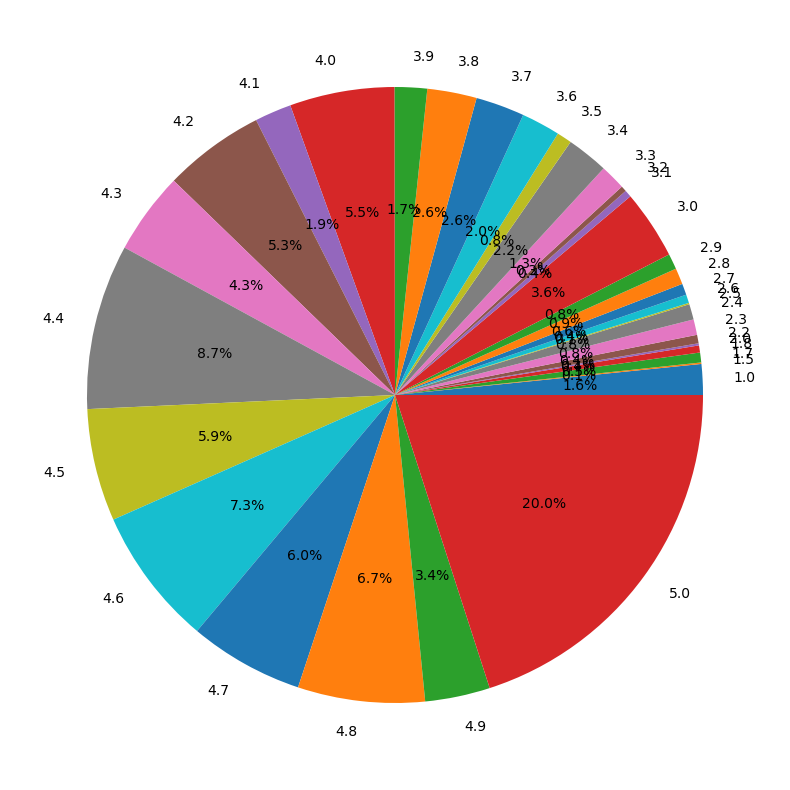

In [108]:
plt.figure(figsize=(14,10))
plt.pie(Rating_installs.values, labels = Rating_installs.index, autopct = "%1.1f%%")
plt.show()

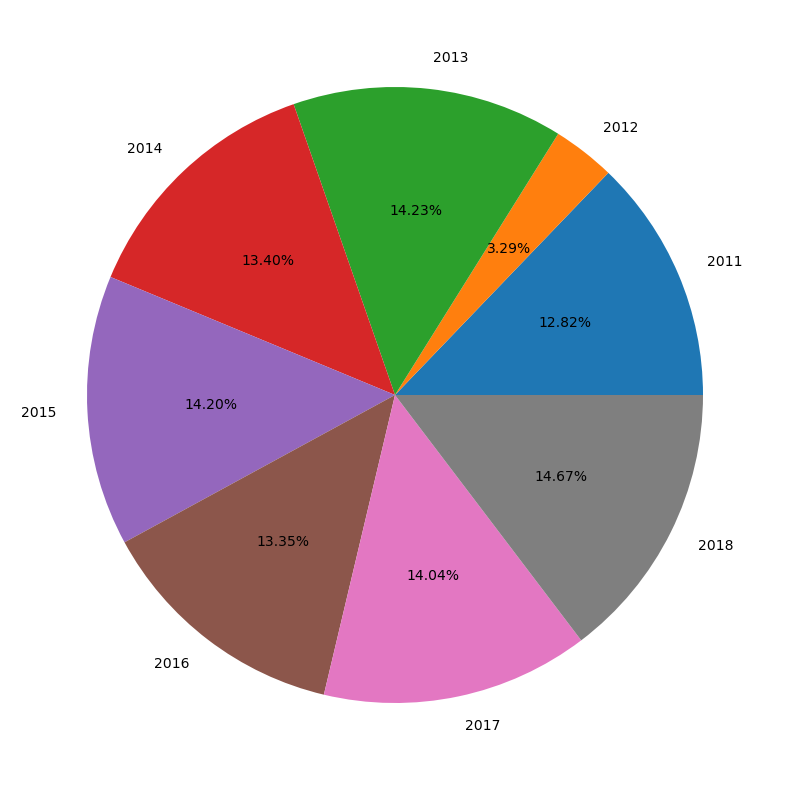

In [110]:
# plt a pie chart for Year wise rating

year_rat = df.groupby('Year')['Rating'].mean()
year_rat
plt.figure(figsize=(14,10))
plt.pie(year_rat.values, labels = year_rat.index, autopct = "%0.2f%%")
plt.show()

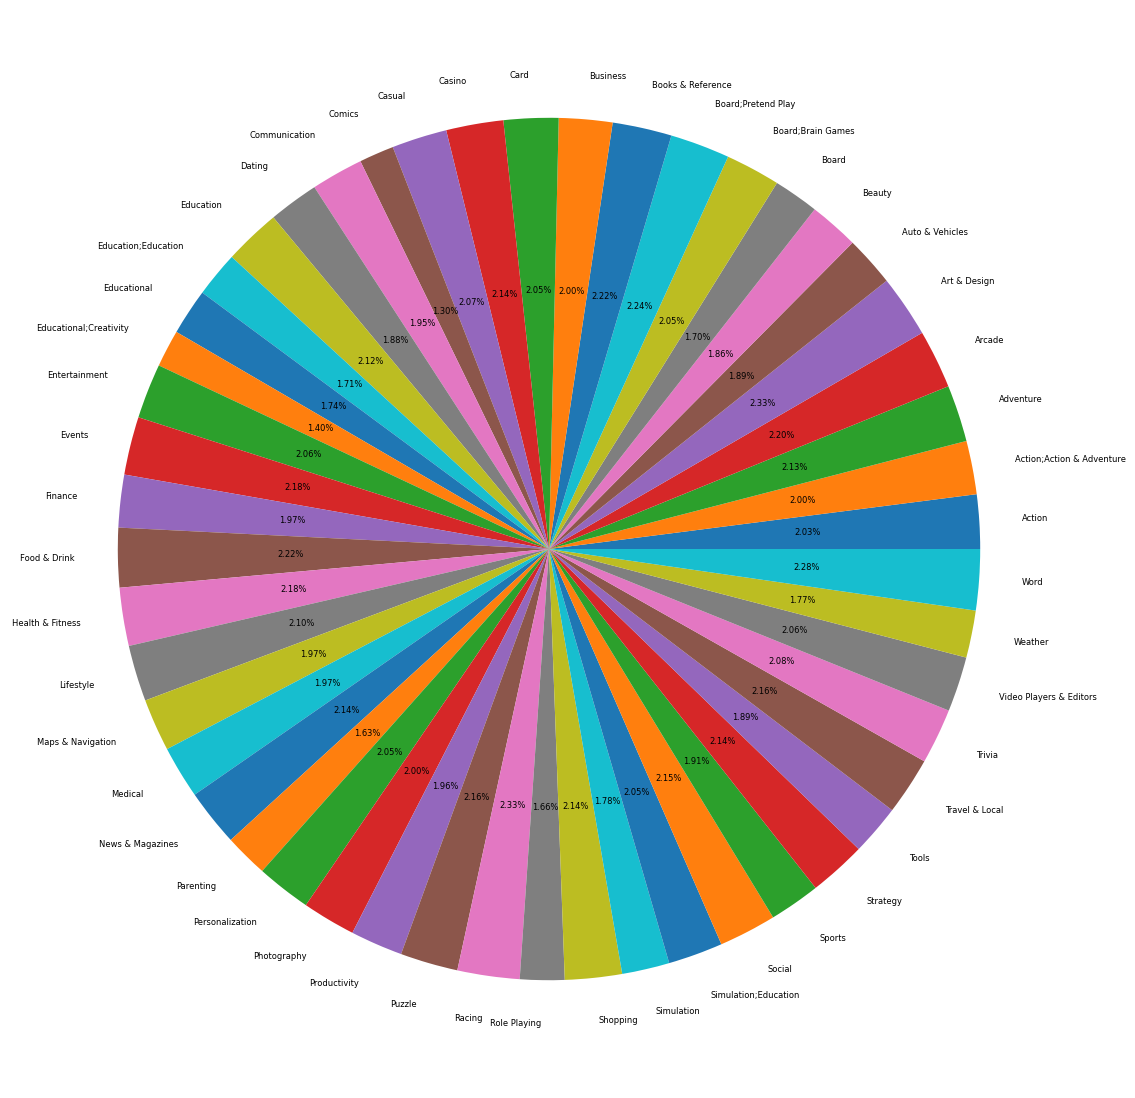

In [112]:
#plt a pie chart for Genres vs Rating..

genres_rat = df.groupby('Genres')['Rating'].mean()

plt.figure(figsize=(14,14))
plt.pie(genres_rat.values, labels = genres_rat.index, autopct = '%0.2f%%', textprops={'fontsize': 6})
plt.show()


<Axes: xlabel='Rating', ylabel='Price'>

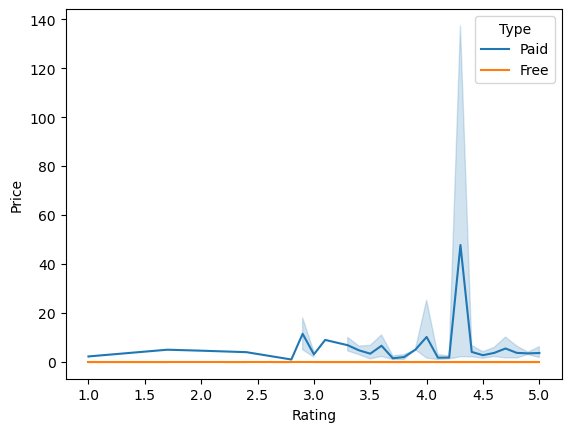

In [114]:
##Difference between the matplotlib and seaborn

# we cannot plot two categories in the matplotlib but in seaborn it is done using hue
# Also we don't have to mention  xlables and ylabels in seaborn , but in the matplot lib we have to mention it.
# In Seaborn  performs agreggation by itself , but in the matplotlib we have to mention by ourselves.

# sns.lineplot(x = colname, y = col_name, hue =category(optional))

# sns.lineplot( x=colname, y= col_name, data = dataframe, hue=Category)

# Example

sns.lineplot(x = df['Rating'], y= df['Price'], hue = df['Type'])

# the Shaded region represents the range of the values.. of price for the ratings.

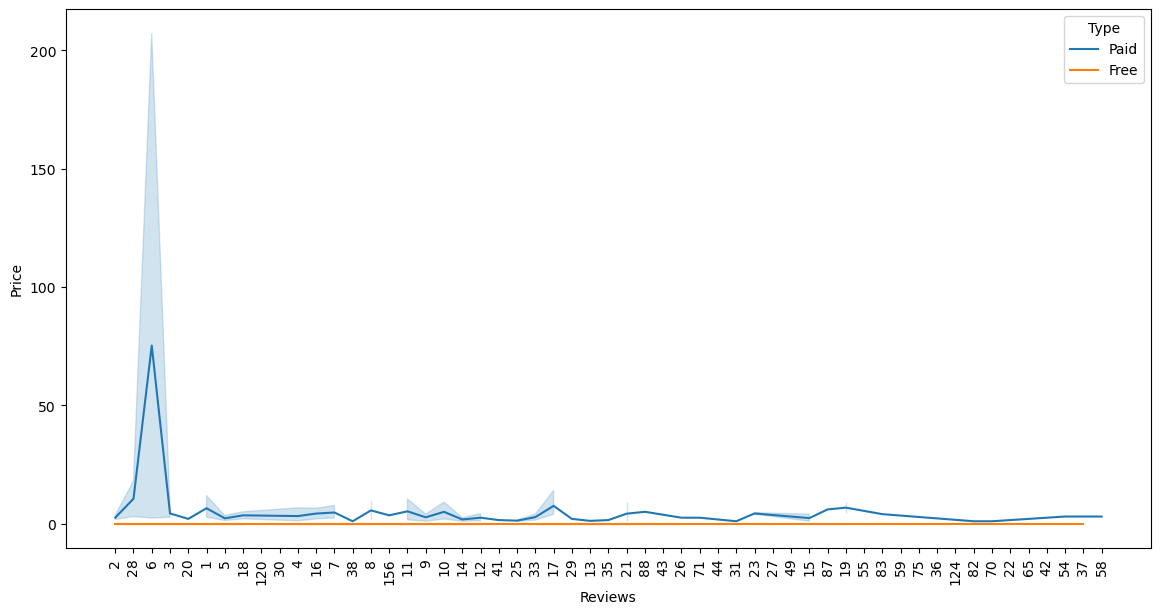

In [115]:
plt.figure(figsize = (14,7))
sns.lineplot(x= 'Reviews', y = 'Price', data = df, hue= 'Type') 

# if we remove data = df and then give hue = 'type ' it will be 
# Value Error! as it will not understand where and which column it is so # use sns.lineplot(------------------, hue = df['Type'])

plt.xticks(rotation = 90)
plt.show()

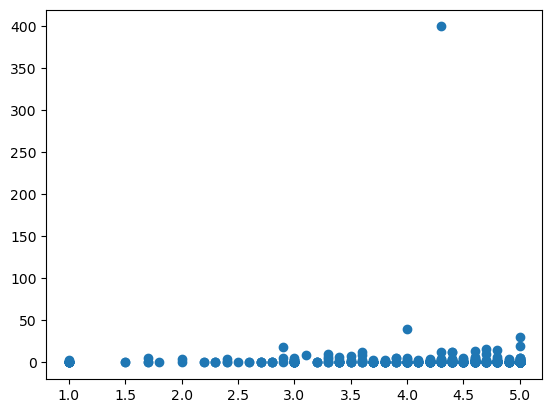

In [117]:
# Rating vs Price  
#plotting the scatter plt using matplotlib


plt.scatter(df['Rating'],df['Price'])

<Axes: xlabel='Rating', ylabel='Price'>

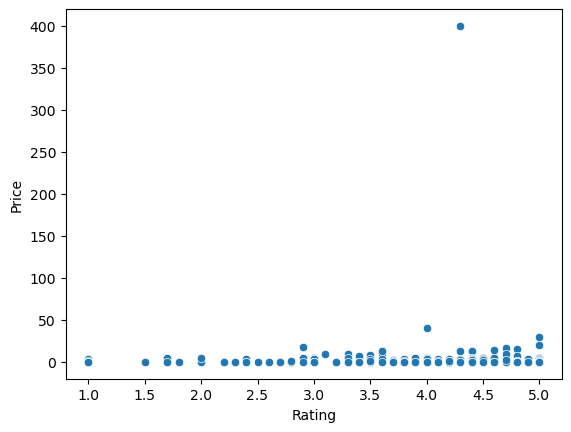

In [120]:
#scatter plot using seaborn

sns.scatterplot(x=df['Rating'], y=df['Price'])

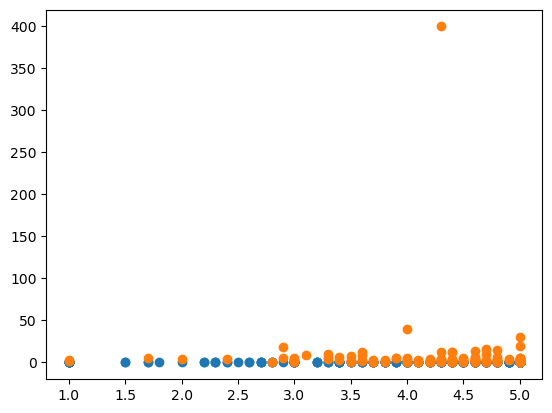

In [122]:
#Use the dataset to extract the free and paid from the 'Type'

type_group = df.groupby('Type')

group_free = type_group.get_group('Free')

group_paid = type_group.get_group('Paid')

plt.scatter(group_free['Rating'],group_free['Price'])
plt.scatter(group_paid['Rating'], group_paid['Price'])

<Axes: xlabel='Rating', ylabel='Price'>

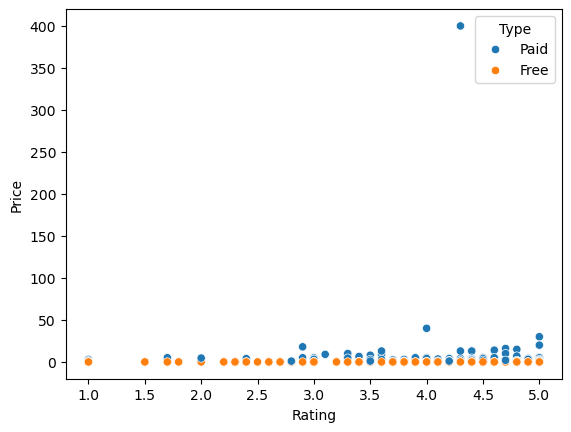

In [124]:


#Another approach using filter method

group_free = df[df['Type'] == 'Free']
group_paid = df[df['Type'] != 'Free']

sns.scatterplot(x = df['Rating'], y = df['Price'] , hue = df['Type'])


In [126]:
# to find the conclusion wheter it is positive / negative or no relation , use corr matrix to conclude it..


df[['Rating','Price']].corr()

# Conclusion :-  It is almost 1.2% relation , which means , it is No relation , and change in x(Rating) doesn't affect the y(Price) values..


,Rating,Price
Rating,1.00000,-0.01244
Price,-0.01244,1.00000


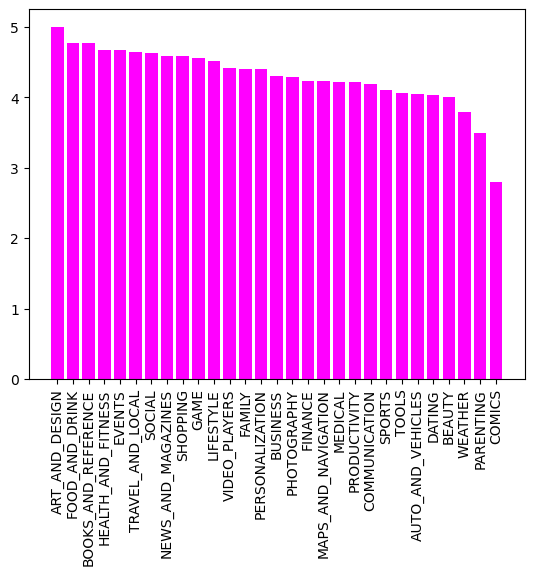

In [128]:
# Bar plot using matplotlib and seaborn 


cat_rat = df.groupby('Category')['Rating'].mean().sort_values(ascending = False)

plt.bar(cat_rat.index, cat_rat.values, color = 'magenta')
plt.xticks(rotation = 90)
plt.show()

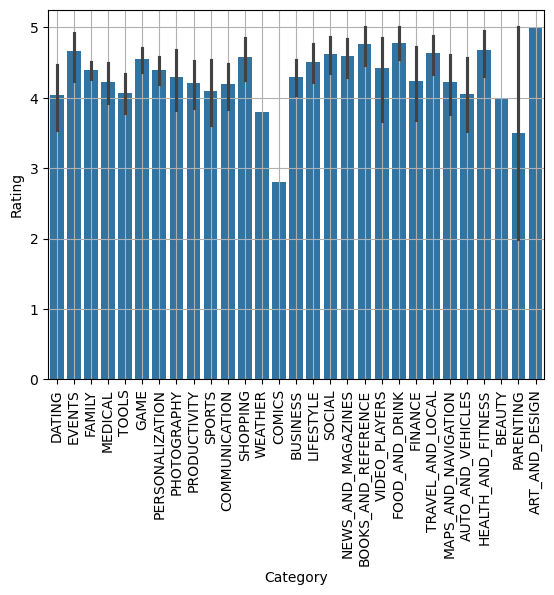

In [130]:
# using the seaborn for barplot.. , it uses by default the groupy and aggregate functions as compared to matplotlib.

# the bold black line shows the mean values..

sns.barplot(x = df['Category'], y = df['Rating'])
plt.xticks(rotation = 90)
plt.grid()
plt.show()

<Axes: xlabel='Year', ylabel='Rating'>

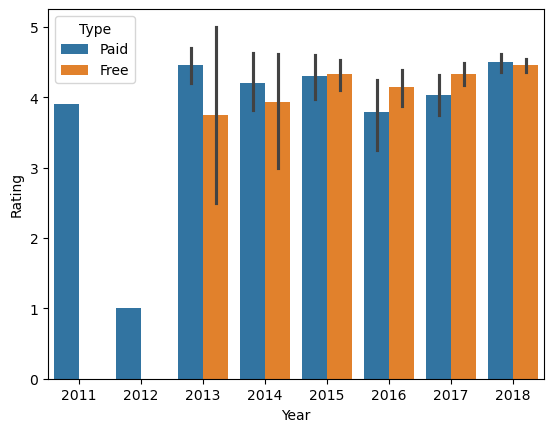

In [132]:
sns.barplot(x = df['Year'], y = df['Rating'], hue = df['Type'])

<Axes: >

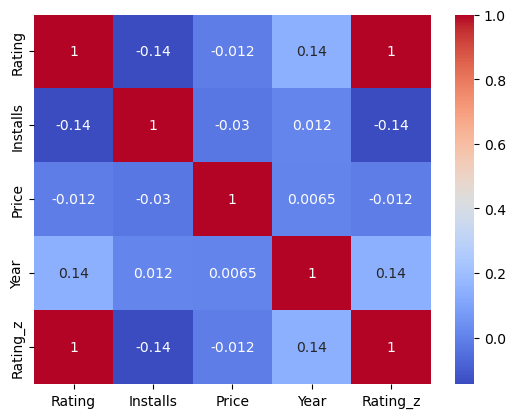

In [134]:
# we use the heatmap to display the correlation between numericals columns..we can usee correlation matrix as well.

sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')

In [136]:

# Correlation 

# >80% -> very strong relation 
# 70-80 -> strong Relation 

# 50-70 -> The Avg relation 

# 30->50 -> Weak Relation 

# 20-30 -> Very Weak Relation 

# <20 -> Almost No Relation




In [138]:
# This is an important concept..

# a,b,c = [10,20,30]

# print(a, type(a))
# print(b, type(b))
# print(c, type(c))


#Different ways to create tuple
# t = (1,'x', 4)
# t1 = 1,2, 3

# print(t, type(t))
# print(t1,type(t1))

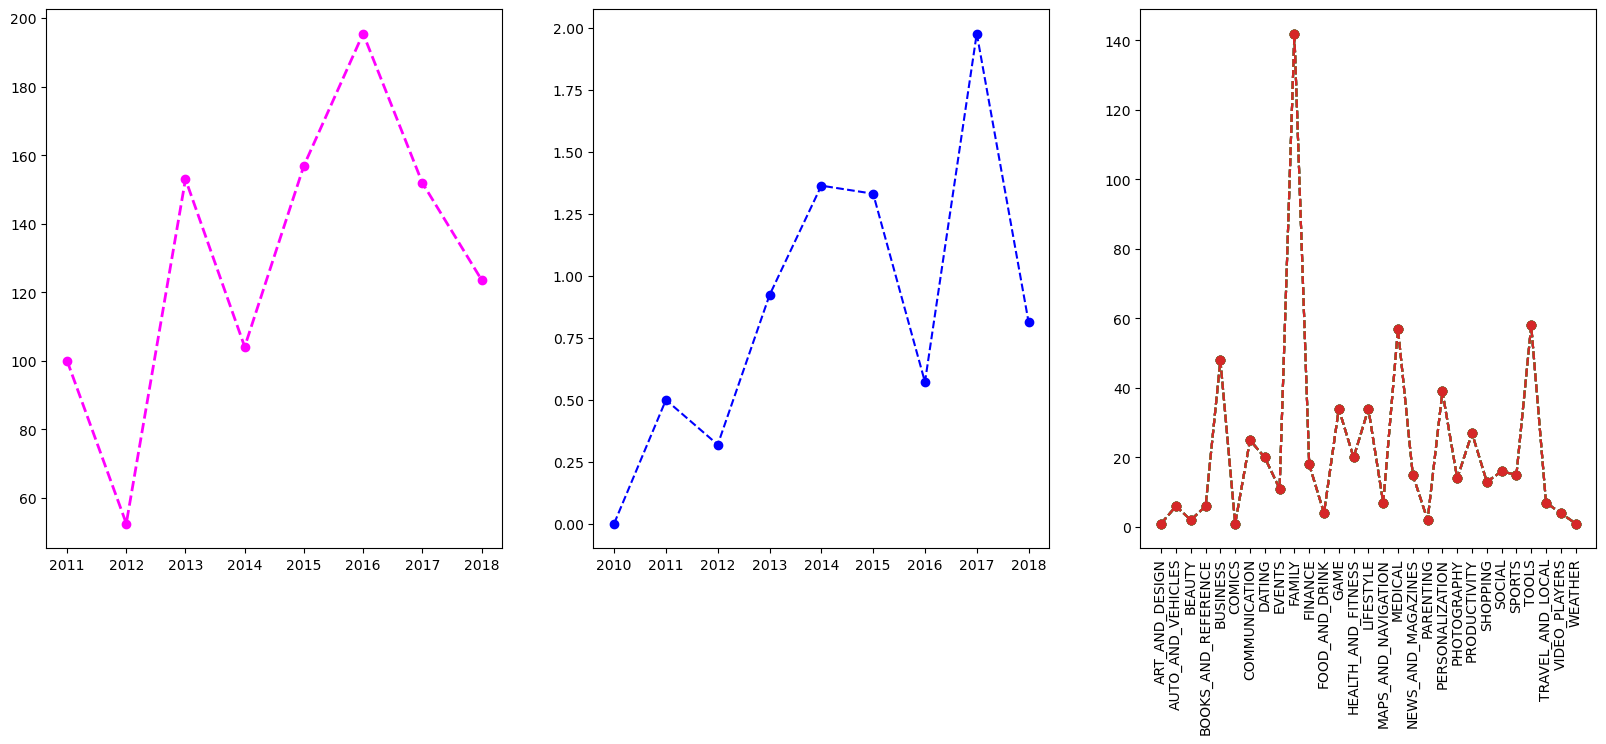

In [140]:
# Subplots()   : We use it plot multiple plots in the same visuals..

#syntax 
# fig , ax = plt.subplots(nrow = n1, ncol = n2, figsize = (20,10))

fig , ax = plt.subplots(1,3, figsize=(20,7))


ax[0].plot(avg_installs,marker='o', linestyle = '--', linewidth = 2, color = 'magenta')
ax[1].plot(avg_price, marker = 'o', color = 'blue', linestyle = 'dashed')

ax[2].plot(cat_count, marker = 'o', linestyle = 'dashed')
plt.xticks(rotation = 90)
plt.show()

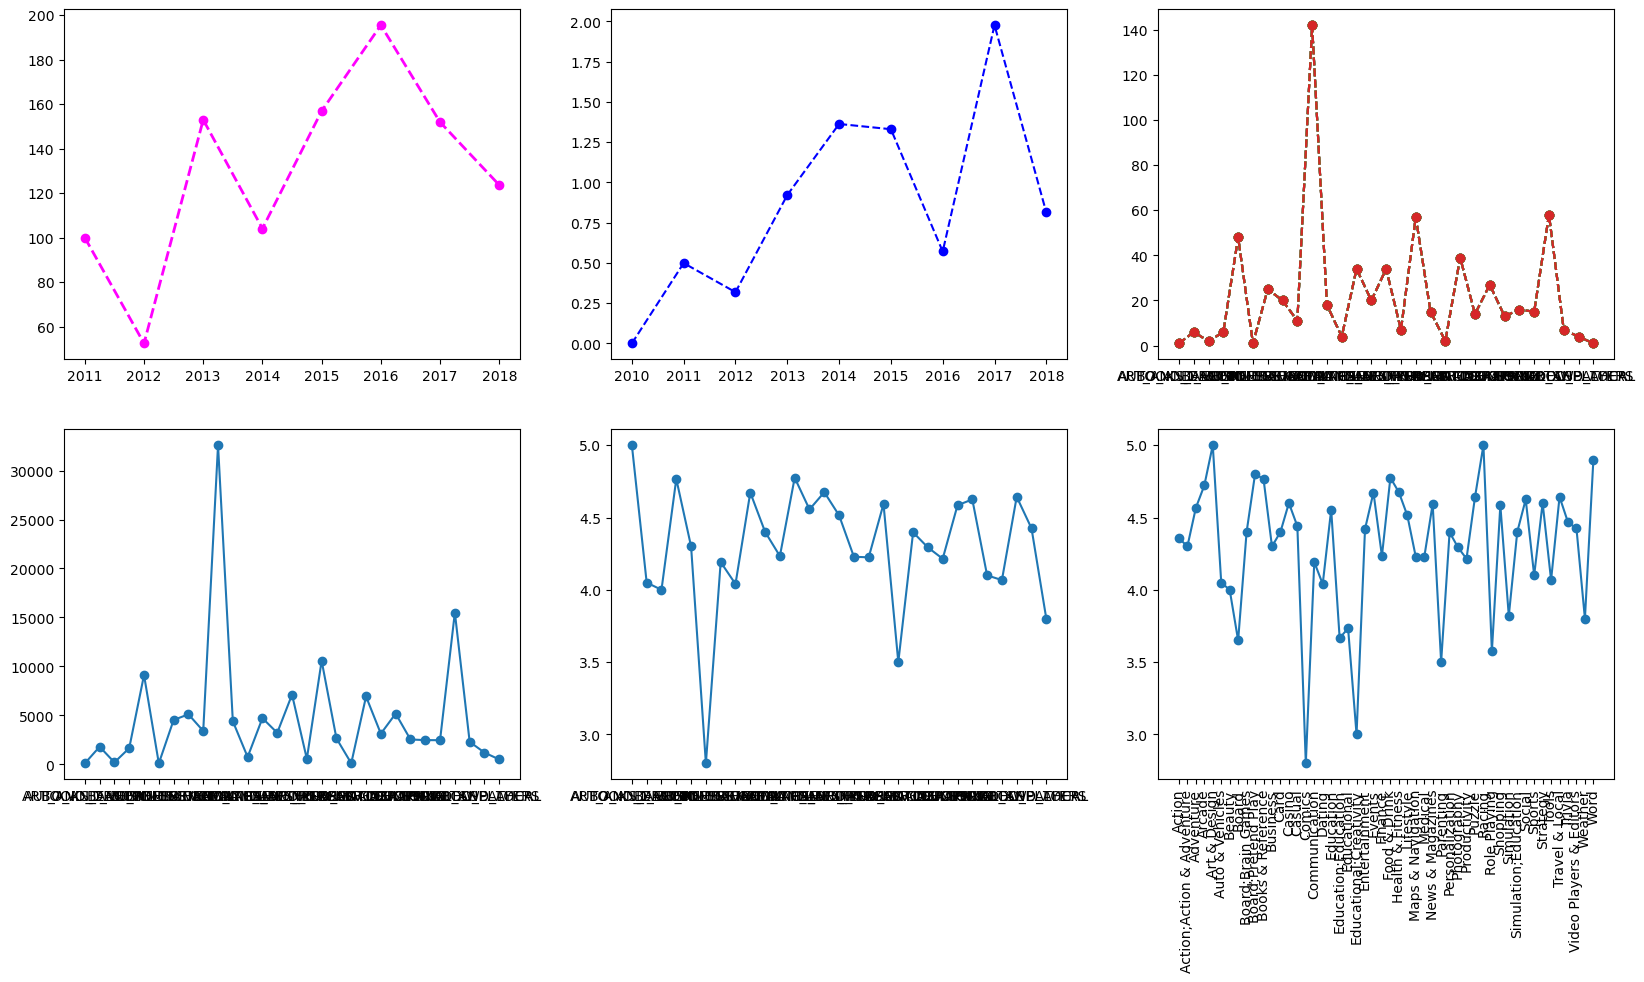

In [142]:
fig, ax  = plt.subplots(2,3, figsize = (20,10))

ax[0][0].plot(avg_installs,marker='o', linestyle = '--', linewidth = 2, color = 'magenta')
ax[0][1].plot(avg_price, marker = 'o', color = 'blue', linestyle = 'dashed')

ax[0][2].plot(cat_count, marker = 'o', linestyle = 'dashed')

ax[1][0].plot(Cat_Install, marker = 'o')
ax[1][1].plot(cat_rating, marker = 'o')
ax[1][2].plot(genres_rat, marker = 'o')
plt.xticks(rotation = 90)
plt.show()

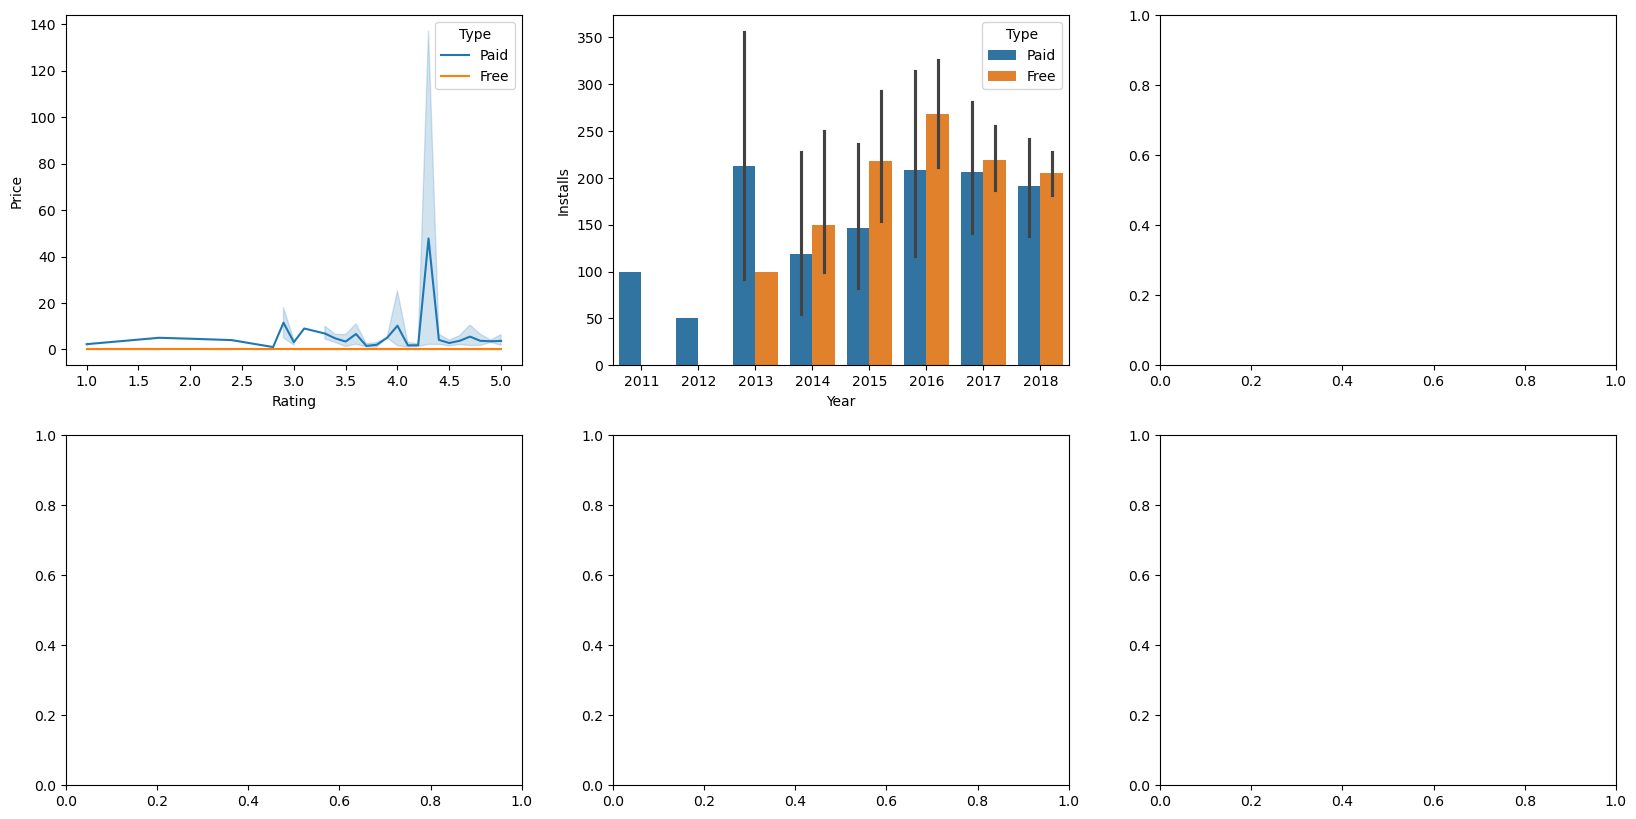

In [144]:
#Plotting the subplots   using the seaborn..

fig , ax = plt.subplots(2,3, figsize = (20,10))

sns.lineplot(x = df['Rating'], y = df['Price'], hue = df['Type'] ,ax = ax[0,0])
sns.barplot(x = 'Year', y = 'Installs', data = df, hue = 'Type', ax = ax [0,1])

# fig.savefig('output.png')



<Axes: xlabel='Year', ylabel='Rating'>

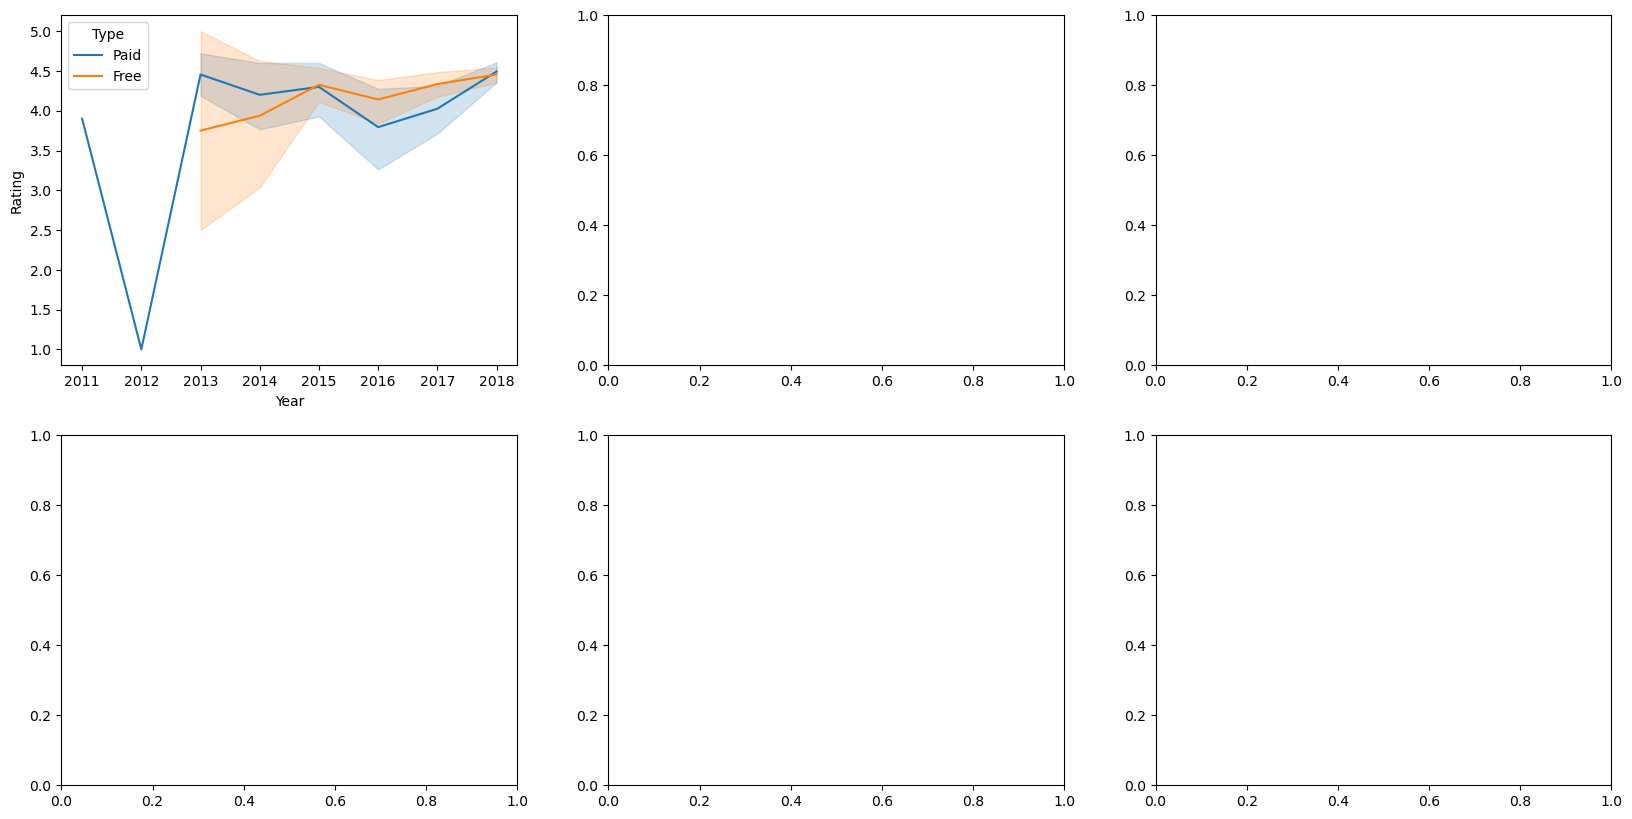

In [154]:
fig, ax = plt.subplots(2,3, figsize = (20,10))
sns.lineplot(x='Year', y = 'Rating', data = df, hue = 'Type', ax = ax[0,0])

In [ ]:
import pandas as pd

# we are working on a new dataset right now, it is called uber dataset..
# Here , We are going to analyze the fare amount wsiht respect to hours, week_day , month, year , passenger_count etc.
df = pd.read_csv('uber.csv')

# df.shape # here shape is not a method but it is a variable..

row, colm = df.shape

print(f'Rows : {row} \nColms: {colm}')


In [ ]:
df.info()

In [ ]:

# count the missing or the null values..

df.isnull().sum()

In [ ]:
# to drop the duplicates, records.. it deletes the entire record if it is duplicate..

df = df.drop_duplicates()

df.info()

# When we use dropna..and Fillna..

#case 1 : When the column is important and has less missing values ( 5 -10 % ) then we will proceed with fillna.
#case 2 : When the column has more missing values such as 70% or less missing values 5-10% then we will proceed with Dropna..


# when we use mean and median .
# we use mean in the columns when the columns values doesn't have outliers as mean is very sensitive to outlier , however we proceed with 
# median values when the columns have outliers and mode is used for the categorical data / columns..



In [1]:
# To check whether the fare_amount column have less fare amount than zero..

df(df['fare_amount'] < 0) # to drop these values.. do the next line 

df = df(df['fare_amount'] > 0) 
df.head()

NameError: name 'df' is not defined

In [3]:
# check whether the pickup_datetime and key has same values or not.

df = df(df['pickup_datetime'] == df['key'])

NameError: name 'df' is not defined

In [5]:
#convert the key to date time format..

df['key'] = pd.to_datetime(df['key'])


# Extracting the day , month and year from the converted format.

df['Day'] = df['key'].dt.day
df['Month']  = df['key'].dt.month
df['Year'] = df['key'].dt.year


#extracting the hours 

df['Hour'] = df['key'].dt.hour
df['Weekday'] = df['key'].dt.weekday

NameError: name 'pd' is not defined

In [7]:
# drop the Unnamed  column from the dataset..


df.drop('Unnamed': 0, axis = 1, inplace = True) # inplace = True will directly replace it in the existing DataFrame



# check whether the passenger count is less than zero..

df(df['passenger_count']< 0)


# After anlayzing the complete dataset , write 20 conclusions..

SyntaxError: invalid syntax (1713262404.py, line 4)

In [12]:
# I have been given a few questions on the dataset of sample superstrore.csv..

import pandas as pd


In [14]:
df1 = pd.read_csv("superstore.csv")
df1.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11/8/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,6/12/16,6/16/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10/11/15,10/18/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10/11/15,10/18/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [62]:
df1.shape

(10296, 21)

In [16]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10296 entries, 0 to 10295
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10296 non-null  object 
 1   Order ID       10296 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quanti

In [18]:
# find numerical and categorical columns..

df1

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11/8/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,6/12/16,6/16/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10/11/15,10/18/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10/11/15,10/18/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10291,Person,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10292,Anna Andreadi,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10293,Chuck Magee,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10294,Kelly Williams,Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
#drop duplicate rows..

df1.drop_duplicates()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11/8/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,6/12/16,6/16/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10/11/15,10/18/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10/11/15,10/18/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10291,Person,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10292,Anna Andreadi,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10293,Chuck Magee,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10294,Kelly Williams,Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df1.shape

(10296, 21)

In [24]:
df1['Order Date'] = pd.to_datetime(df1['Order Date'])
df1['Ship Date'] = pd.to_datetime(df1['Ship Date'])
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10296 entries, 0 to 10295
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         10296 non-null  object        
 1   Order ID       10296 non-null  object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   float64       
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994

/var/folders/zx/4wml1k7n6ml37j348fx1w4400000gn/T/ipykernel_86841/54508761.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Order Date'] = pd.to_datetime(df1['Order Date'])
/var/folders/zx/4wml1k7n6ml37j348fx1w4400000gn/T/ipykernel_86841/54508761.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Ship Date'] = pd.to_datetime(df1['Ship Date'])


In [26]:

# Extract Year and Month

df1['Year'] = df1['Order Date'].dt.year
df1['Month'] = df1['Order Date'].dt.month
df1.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,2016.0,11.0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,2016.0,11.0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,2016.0,6.0
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,2015.0,10.0
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,2015.0,10.0


In [28]:
# convert postal code to numeric columns 

df1['Postal Code'].dropna()
df1['Postal Code'] = df1['Postal Code'].replace({'NA','' , 'inf' , ''})
df1['Postal Code'].astype(int)



df1['Postal Code']

/var/folders/zx/4wml1k7n6ml37j348fx1w4400000gn/T/ipykernel_86841/2388985947.py:4: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df1['Postal Code'] = df1['Postal Code'].replace({'NA','' , 'inf' , ''})


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [30]:
import pandas as pd 
import matplotlib.pyplot as plt
# find outliers in Sales and profit..

#Calculating the z score values..

def z_score(col):
    x_mean = col.mean()
    x_std = col.std()
    X = col
    return (X - x_mean) / x_std
  

df1['Profit_z'] = z_score(df1['Profit'])
df1['Profit_z']


# plot the box plot I'll find the q1 and q3 values and then values out of the range of q1 and q3, will give me an outlier..




0        0.056590
1        0.815013
2       -0.092997
3       -1.757397
4       -0.111587
           ...   
10291         NaN
10292         NaN
10293         NaN
10294         NaN
10295         NaN
Name: Profit_z, Length: 10296, dtype: float64

In [1]:
# we are learning the numpy now...

import numpy as np

arr = np.array([[1,2,3],[4,5,6],[7,8,9]])

arr

#slicing the array

arr[0:2: ]  # index = 2 is Excluded.

array([[1, 2, 3],
       [4, 5, 6]])

In [2]:
arr[ : : -1] # it will reverse it.


arr[: 2,3:]

array([], shape=(2, 0), dtype=int64)

In [3]:
# random : It is a module that is used to generate a random values.

values = np.random.rand()  # random float values b/w 0 and 1

val = np.random.randint(1,20)  # generates integer val b/w 1 and 20

In [7]:
# random number guessing game... if the number is higher, give clue as higher, if lesser , give clue as lesser...


rand_no = np.random.randint(1,100)
count = 0

while True:

    number = int(input('Guess the number..... '))

    if rand_no == number: 
        print('Yahh! You have guessed the number correctly')
        count+=1
        print(f'You took {count} attempts to guess the number correctly')
        break

    elif(rand_no > number):
        print(f'Ohoo! The number {number}  you have guessed is lesser than the random number \nChoose Number greater than this ')
       

    else:
        print(f'Ohoo! The number {number}  you have guessed is greater than the random number \nChoose Number lesser than this ')
       
    count+=1

Guess the number.....  34


Ohoo! The number 34  you have guessed is greater than the random number 
Choose Number lesser than this 


Guess the number.....  25


Ohoo! The number 25  you have guessed is greater than the random number 
Choose Number lesser than this 


Guess the number.....  12


...

Ohoo! The number 15  you have guessed is greater than the random number 
Choose Number lesser than this 


Guess the number.....  13


Ohoo! The number 13  you have guessed is lesser than the random number 
Choose Number greater than this 


Guess the number.....  14


Yahh! You have guessed the number correctly
You took 7 attempts to guess the number correctly


In [8]:

# Next method is choice.....in numpy

# choice = np.random.choice(l1)

# game with the computer of stone , paper , scissors..

l1 = ['stone', 'paper', 'scissor']

c_score = 0
p_score = 0


for i in range(3):

    p_guess = input('Enter your guess....')
    c_guess=np.random.choice(l1)

    if p_guess == 'stone' and c_guess == 'paper':
        c_score += 1

    elif  p_guess == 'paper' and c_guess == 'stone':
        p_score +=1

    elif  p_guess == 'stone' and c_guess == 'scissor':
        p_score +=1
        

    elif p_guess == 'scissor' and c_guess == 'stone':
        c_score +=1

    elif  p_guess == 'scissor' and c_guess == 'paper':
        p_score += 1

    elif  p_guess == 'paper' and c_guess == 'scissor':
        c_score +=1
    else:
        print('Tie')

if(c_score == p_score):
    print('Tie')
elif c_score > p_score:
    print('computer won')
else:
    print('Person Won')


Enter your guess.... scissor
Enter your guess.... stone


Tie


Enter your guess.... paper


Tie


In [11]:
# if we have to select 5 random values b/w 1 and 100

np.random.randint(1,100,5)


array([62, 41, 79, 87, 17])

In [13]:
# If we have to select 2 rows and 5 columns..
arr = np.random.randint(1,100,[2,5])
arr

array([[95, 84, 44, 22, 45],
       [ 8, 31, 63, 75, 98]])

In [15]:
# we can use aggregation function on it.., like sum , avg..

np.sum(arr)

565

In [17]:
# to add row wise..

np.sum(arr,axis = 0) # axis = 0 means select columns and perform operation row wise..

array([103, 115, 107,  97, 143])

In [19]:
np.sum(arr, axis = 1) # axis - 1 means select rows and perform operation column wise..

array([290, 275])

In [21]:
# to add the third columns values..

third_col = arr[:,2]
np.sum(third_col)

107

In [23]:
# np.random.seed(None) # this helps in generating the different set of values everytime..
np.random.seed(42)  # this helps in controlling the randomness of the values..

arr = np.random.randint(1,100,[2,5])
arr

array([[52, 93, 15, 72, 61],
       [21, 83, 87, 75, 75]])

In [25]:
# to find the unique elements..in the array 

# np.unique(arr, return_counts = True)


#unpacking this..

unique_values, counts = np.unique(arr, return_counts = True)

unique_values ,counts


(array([15, 21, 52, 61, 72, 75, 83, 87, 93]),
 array([1, 1, 1, 1, 1, 2, 1, 1, 1]))

In [27]:

# in the numpy we dont have mode, we have to define the user defined fuction , where we have to return the mode value in 
# numpy..

arr = np.array([1,3,2,3,2,3,1])

values , counts = np.unique(arr, return_counts = True)

counts

array([2, 2, 3])

In [35]:
#the max count is shown , i will print its value.

max_index = np.argmax(counts)
max_index

print(values[max_index])

3

In [61]:
# Flatten the list..(In the list we dont have flatten method)

l = [[1,2],[4,5],10]    # Expected output [1,2,4,5,10]

# a,b,c = l

# l1 = []
# x,y = a
# d,e = b

# l1.append(x)
# l1.append(y)
# l1.append(d)
# l1.append(e)
# l1.append(c)

# print(l1)


# approach 2: Iterate and then check if it's type is list then extend or concatenate or if it is just a value append the value..

l1 = []

for i in l:

    if type(i) == list:
        l1.extend(i)

    else:
        l1.append(i)

print(l1)


[1, 2, 4, 5, 10]


In [95]:
# flatten the array is an inbuilt method in the array , that converts 2D into 1D

arr = np.array([[2,38,9,35,98,63],[3,4,3,52,4,5]])
arr1 = arr.flatten()  # return new 1D array..

arr1


array([ 2, 38,  9, 35, 98, 63,  3,  4,  3, 52,  4,  5])

In [109]:
# reshape...: we can change the rows and columns..

#arr.reshape(10,3) #cannot reshape array of size 12 into shape (10,3)

# arr1 = 2X6 dimension, so we can convert it into 6X2 , 12X1, 1X12

# arr1.reshape(12,1)
arr1.reshape(1,12)
# arr1.reshape(6,2)

array([[ 2, 38,  9, 35, 98, 63,  3,  4,  3, 52,  4,  5]])

In [103]:
arr.reshape(-1) 

array([ 2, 38,  9, 35, 98, 63,  3,  4,  3, 52,  4,  5])

In [115]:
# Resize method.. updates in the same array... However reshape method return new array..

arr1.resize(12,1)
arr1

array([[ 2],
       [38],
       [ 9],
       [35],
       [98],
       [63],
       [ 3],
       [ 4],
       [ 3],
       [52],
       [ 4],
       [ 5]])

In [167]:
# two array and find var(x), var(y) and cov(x) and then cov(y) without using inbuilt method.

#var(x) = sum(xi - x_bar)^2 / n
#cov(x,y) = (sum(xi - x_bar) * (yi-y_bar)) ^ 2 / n

x = np.array([10,20,30,40,50])
y = np.array([100,200,300,400,500])


mean_x = x.mean()
mean_y = y.mean()
var_x = 0
var_y = 0
for i in x:
    var_x  += (i-mean_x)**2 / len(x)


# Another way to do it..    
# var_x = np.sum((x-np.mean(x)) ** 2) / len(x)

print("Variance of X:", var_x)


for j in y:
    var_y += (j - mean_y) ** 2 / len(y)
print("Variance of Y:", var_y)


# the covariance(x,y)
cov_xy = 0

for i in range(len(x)):
    cov_xy += ((x[i] - mean_x) * (y[i] - mean_y)) / len(x)


# Another Approach to find the covariance.
# cov_xy = np.sum((x-np.mean(x)) * (y - np.mean(y)))/len(x)

print("Covariance of X and Y is: ", cov_xy)


Variance of X: 200.0
Variance of Y: 20000.0
Covariance of X and Y is:  2000.0


In [1]:
# Machine Learning .. 

import pandas as pd
import numpy as np



# df = pd.read_csv('SampleSuperstore1.csv')
# df.head(2)
df = pd.DataFrame()
df['Years_Experience'] = np.random.randint(1,5,5)
df['Salary'] = np.random.randint(10000,50000, 5)

df.head()

,Years_Experience,Salary
0,3,38248
1,1,39802
2,1,30306
3,2,11757
4,4,30915


In [3]:
df.corr()*100

df1 = pd.DataFrame({'Years_exp':[1.1, 2.3, 1.3, 1.5, 3.2, 3.5], 
                    'salary':[12000, 28500, 13500, 18700, 40000, 45999]})

<Axes: xlabel='Years_exp', ylabel='salary'>

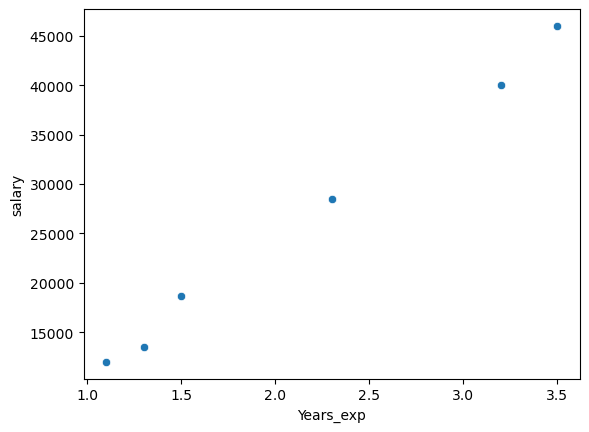

In [5]:
df1.corr()*100

import seaborn as sns
sns.scatterplot(data = df1, x = 'Years_exp', y = 'salary')

<Axes: xlabel='Years_exp', ylabel='salary'>

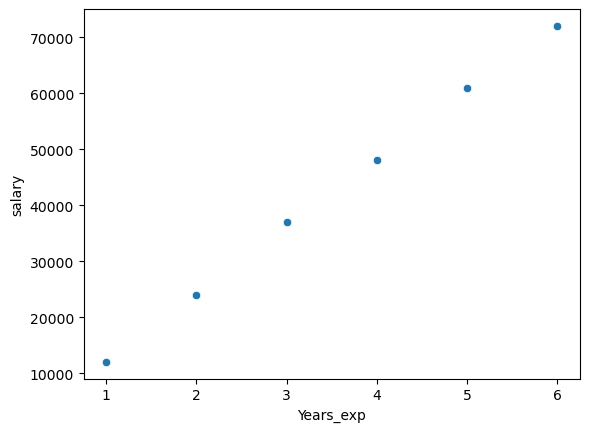

In [6]:
df1 = pd.DataFrame({'Years_exp':[1, 2, 3, 4, 5, 6], 
                    'salary':[12000, 24000, 37000, 48000, 61000, 72000]})

sns.scatterplot(data = df1, x = 'Years_exp', y = 'salary')

In [7]:
df1.head()

,Years_exp,salary
0,1,12000
1,2,24000
2,3,37000
3,4,48000
4,5,61000


In [ ]:
# in Linear Regression..
# y = mx+c , here m and c is decided during the model training..


# Slope : Rate of change of y with respect to x when x is increased or decreased by 1 unit..

# Here m = 5 and c = 20 here marks changes by 5 marks when study hours increase or decrease by 1 unit..



# conclusion : for Every 1 squre feet of area increase or decrease in the plot.. the house price will increase/Decrease  by Rs 5000 


# Slope can calculated..using this  : cov(x,y) / var(x) 

# where var(x)  =  Summation (xi - x^bar) ** 2 / n

# cov(x,y) = (summation (xi - x^bar) * (yi - y^bar) ) / n 

# so Slope  =  Summation(xi - x^bar) * (yi - y^bar) ) / Summation(xi - x^bar) ** 2

# Intercept = Y^bar - (slope * X ^bar) jj 

